In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP245"

# EXP1 = "SSP245"     # subtrahend  (delta = EXP1 - EXP2)
# EXP2 = "HIST"

In [2]:
# output_file = "./analysis_transient_data/Seager_decomposition_G6sulfur_minus_SSP245.nc"
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Seager_decomposition_G6sulfur_minus_SSP245.nc"

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))



In [5]:
# """
# SEAGER DECOMPOSITION SECTION
# Based on Seager et al. (2010) J. Climate
# """

# # =========================
# # Physical constants
# # =========================
# Cp = 1005.0    # J kg-1 K-1
# Lv = 2.5e6     # J kg-1
# g  = 9.81      # m s-2
# rho_w = 1000.0 # kg m-3

# # Pressure levels for vertical structure
# P_TOP = 10000.0    # 100 hPa
# P_SFC = 101300.0   # 1013 hPa


# # ================================================================
# # SEAGER DECOMPOSITION FUNCTIONS
# # ================================================================

# def vertical_integral(da):
#     """Mass-weighted vertical integral."""
#     da = da.sortby("plev")
#     return (da.integrate("plev") / g)


# def compute_horizontal_gradient(da, var_name='q'):
#     """Compute horizontal gradient ∇q."""
#     lat_rad = np.deg2rad(da.lat)
#     R_earth = 6.371e6  # meters
    
#     dlon = np.deg2rad(np.gradient(da.lon.values)[0])
#     dvar_dlon = da.differentiate("lon") / dlon
    
#     dlat = np.deg2rad(np.gradient(da.lat.values)[0])
#     dvar_dlat = da.differentiate("lat") / dlat
    
#     cos_lat = np.cos(lat_rad)
    
#     # Return (∂/∂x, ∂/∂y) components
#     dvar_dx = dvar_dlon / (R_earth * cos_lat)
#     dvar_dy = dvar_dlat / R_earth
    
#     return dvar_dx, dvar_dy


# def compute_MCD(ua, va, hus):
#     """
#     Mean circulation component: -<V>·∇<q>
#     Angle brackets denote time mean.
#     """
#     # Compute gradient of mean moisture
#     dqdx, dqdy = compute_horizontal_gradient(hus, 'q')
    
#     # Mean advection
#     adv = ua * dqdx + va * dqdy
    
#     return -vertical_integral(adv)


# def compute_TED(ua, va, hus, ua_mean, va_mean, hus_mean):
#     """
#     Transient eddy component: -<V'·∇q'>
#     Prime denotes deviation from time mean.
#     """
#     # Compute anomalies
#     ua_prime = ua - ua_mean
#     va_prime = va - va_mean
#     hus_prime = hus - hus_mean
    
#     # Gradient of moisture anomaly
#     dqpdx, dqpdy = compute_horizontal_gradient(hus_prime, 'q')
    
#     # Transient eddy flux
#     eddy_flux = ua_prime * dqpdx + va_prime * dqpdy
    
#     return -vertical_integral(eddy_flux)


# def compute_thermodynamic_component(ua_mean, va_mean, delta_hus):
#     """
#     Thermodynamic component: -<V>·∇(Δq)
#     """
#     dqdx, dqdy = compute_horizontal_gradient(delta_hus, 'q')
    
#     adv = ua_mean * dqdx + va_mean * dqdy
    
#     return -vertical_integral(adv)


# def compute_dynamic_component(delta_ua, delta_va, hus_mean):
#     """
#     Dynamic component: -ΔV·∇<q>
#     """
#     dqdx, dqdy = compute_horizontal_gradient(hus_mean, 'q')
    
#     adv = delta_ua * dqdx + delta_va * dqdy
    
#     return -vertical_integral(adv)


# def compute_nonlinear_component(delta_ua, delta_va, delta_hus):
#     """
#     Nonlinear component: -ΔV·∇(Δq)
#     """
#     dqdx, dqdy = compute_horizontal_gradient(delta_hus, 'q')
    
#     adv = delta_ua * dqdx + delta_va * dqdy
    
#     return -vertical_integral(adv)


# def calculate_seager_components(ds_pr, ds_ev, ds_ua, ds_va, ds_hus):
#     """
#     Calculate Seager et al. (2010) decomposition components.
    
#     For a single experiment (time series).
#     Returns dictionary with: P, E, MCD, TED
#     """
#     # Extract variables
#     pr = ds_pr['pr'] if isinstance(ds_pr, xr.Dataset) else ds_pr
#     E = ds_ev['evspsbl'] if isinstance(ds_ev, xr.Dataset) else ds_ev
#     ua = ds_ua['ua'] if isinstance(ds_ua, xr.Dataset) else ds_ua
#     va = ds_va['va'] if isinstance(ds_va, xr.Dataset) else ds_va
#     hus = ds_hus['hus'] if isinstance(ds_hus, xr.Dataset) else ds_hus
    
#     # Fill NaNs
#     ua = ua.fillna(0)
#     va = va.fillna(0)
#     hus = hus.fillna(0)
    
#     # Compute time means (for MCD calculation)
#     print("    Computing time means...")
#     ua_mean = ua.mean(dim='time')
#     va_mean = va.mean(dim='time')
#     hus_mean = hus.mean(dim='time')
    
#     print("    Computing MCD (Mean Circulation)...")
#     MCD = compute_MCD(ua_mean, va_mean, hus_mean)
    
#     print("    Computing TED (Transient Eddies)...")
#     TED = compute_TED(ua, va, hus, ua_mean, va_mean, hus_mean)
    
#     return {
#         'P': pr,
#         'E': E,
#         'MCD': MCD,
#         'TED': TED,
#         'ua_mean': ua_mean,
#         'va_mean': va_mean,
#         'hus_mean': hus_mean
#     }


# def calculate_seager_delta_decomposition(exp1_components, exp2_components):
#     """
#     Decompose ΔP = P(exp1) - P(exp2) into Seager components.
    
#     Returns: thermodynamic, dynamic, nonlinear, transient_eddy changes
#     """
#     # Changes in variables
#     delta_ua = exp1_components['ua_mean'] - exp2_components['ua_mean']
#     delta_va = exp1_components['va_mean'] - exp2_components['va_mean']
#     delta_hus = exp1_components['hus_mean'] - exp2_components['hus_mean']
    
#     # Reference state (exp2 means)
#     ua_ref = exp2_components['ua_mean']
#     va_ref = exp2_components['va_mean']
#     hus_ref = exp2_components['hus_mean']
    
#     print("    Computing thermodynamic component...")
#     thermo = compute_thermodynamic_component(ua_ref, va_ref, delta_hus)
    
#     print("    Computing dynamic component...")
#     dyn = compute_dynamic_component(delta_ua, delta_va, hus_ref)
    
#     print("    Computing nonlinear component...")
#     nonlin = compute_nonlinear_component(delta_ua, delta_va, delta_hus)
    
#     # Change in transient eddies
#     # Seasonal ΔTED (already climatological means)
#     delta_TED = {
#         season: (
#             exp1_components['TED'][season]['mean'] -
#             exp2_components['TED'][season]['mean']
#         )
#         for season in exp1_components['TED']
#     }
    
#     return {
#         'thermodynamic': thermo,
#         'dynamic': dyn,
#         'nonlinear': nonlin,
#         'transient_eddy': delta_TED
#     }


# # ================================================================
# # MAIN PROCESSING LOOP 
# # ================================================================

# import os

# output_file = "./analysis_transient_data/Seager_decomposition_G6sulfur_minus_SSP245.nc"

# if not os.path.exists(output_file):
#     print('#'*40)
#     print("File does not exist — running Seager decomposition")
#     print('#'*40)

#     all_results = {}
    
#     for model_name, model_meta in MODELS.items():
    
#         components_by_exp = {}
#         seasonal_data = {}
    
#         # ----------------------------
#         # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#         # ----------------------------
#         for exp, meta in EXPERIMENTS.items():
    
#             # --- special-case ensemble override ---
#             if model_name == "CESM2-WACCM":
#                 ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#             else:
#                 ensemble = model_meta["ensemble"]
    
#             def make_base(vname):
#                 return (
#                     CEDA_BASE
#                     / meta["project"]
#                     / model_meta["institution"]
#                     / model_name
#                     / meta["scenario"]
#                     / ensemble
#                     / "Amon"
#                     / vname
#                     / model_meta["grid"]
#                     / "latest"
#                 )
    
#             base_pr = make_base("pr")
#             base_ev = make_base("evspsbl")
#             base_ua = make_base("ua")
#             base_va = make_base("va")
#             base_hus = make_base("hus")
            
#             ####### Handle ALTERNATE base paths ######
#             ds_pr = load_model_data_alt_path(base_pr, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "pr")
#             ds_ev = load_model_data_alt_path(base_ev, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "evspsbl")
#             ds_ua = load_model_data_alt_path(base_ua, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "ua")
#             ds_va = load_model_data_alt_path(base_va, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "va")
#             ds_hus = load_model_data_alt_path(base_hus, meta["project"], model_meta["institution"], 
#                                               model_name, meta["scenario"], 
#                                               ensemble, model_meta["grid"], mf, "hus")
            
#             # Roll and regrid
#             ds_pr  = roll_and_regrid(ds_pr)
#             ds_ev  = roll_and_regrid(ds_ev)
#             ds_ua  = roll_and_regrid(ds_ua)
#             ds_va  = roll_and_regrid(ds_va)
#             ds_hus = roll_and_regrid(ds_hus)
            
#             print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months "
#                   f"({ds_pr.time.values[0]} → {ds_pr.time.values[-1]})")
#             print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months "
#                   f"({ds_hus.time.values[0]} → {ds_hus.time.values[-1]})")
    
#             # Calculate Seager decomposition components
#             print(f"  [{model_name}] {exp}: Computing Seager components...")
#             components = calculate_seager_components(ds_pr, ds_ev, ds_ua, ds_va, ds_hus)
#             components_by_exp[exp] = components
    
#             print(f"  [{model_name}] {exp}: All components computed")
    
#         # ----------------------------
#         # 2) SEASONAL MEANS BY YEAR FOR EACH COMPONENT
#         # ----------------------------
#         for exp in components_by_exp:
#             seasonal_data[exp] = {}
            
#             t_start, t_end = _time_slice(exp)
            
#             # For time-varying components (P, E, TED)
#             for comp_name in ['P', 'E', 'TED']:
#                 da = components_by_exp[exp][comp_name]
#                 da_sliced = da.sel(time=slice(t_start, t_end))
#                 n_months = da_sliced.sizes['time']
                
#                 print(f"  [{model_name}] {exp} - {comp_name}: sliced to {n_months} months = "
#                       f"{n_months//12} years")
                
#                 seasonal_data[exp][comp_name] = {
#                     "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
#                     "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
#                     "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
#                 }
            
#             # Store time-mean fields (already computed)
#             seasonal_data[exp]['ua_mean'] = components_by_exp[exp]['ua_mean']
#             seasonal_data[exp]['va_mean'] = components_by_exp[exp]['va_mean']
#             seasonal_data[exp]['hus_mean'] = components_by_exp[exp]['hus_mean']
#             seasonal_data[exp]['MCD'] = components_by_exp[exp]['MCD']
        
#         # ----------------------------
#         # 3) COMPUTE MEANS FOR EACH EXPERIMENT
#         # ----------------------------
#         results = {}
        
#         for exp in seasonal_data:
#             results[exp] = {}
            
#             # Time-varying components
#             for comp_name in ['P', 'E', 'TED']:
#                 results[exp][comp_name] = {}
                
#                 for season in ["SUM", "WIN", "ANN"]:
#                     da_year = seasonal_data[exp][comp_name][season]
                    
#                     results[exp][comp_name][season] = {
#                         "mean": da_year.mean(dim="year"),
#                         "std": da_year.std(dim="year")
#                     }
            
#             # Time-mean fields (no seasonal splitting needed)
#             results[exp]['ua_mean'] = seasonal_data[exp]['ua_mean']
#             results[exp]['va_mean'] = seasonal_data[exp]['va_mean']
#             results[exp]['hus_mean'] = seasonal_data[exp]['hus_mean']
#             results[exp]['MCD'] = seasonal_data[exp]['MCD']
    
#         # ----------------------------
#         # 4) COMPUTE DELTAS (G6sulfur - SSP245)
#         # ----------------------------
#         EXP1 = "G6sulfur"
#         EXP2 = "SSP245"
        
#         if EXP1 in results and EXP2 in results:
#             results["delta"] = {}
            
#             # Simple deltas for P, E, TED
#             for comp_name in ['P', 'E', 'TED']:
#                 results["delta"][comp_name] = {}
                
#                 for season in ["SUM", "WIN", "ANN"]:
#                     delta_mean = (results[EXP1][comp_name][season]["mean"] - 
#                                  results[EXP2][comp_name][season]["mean"])
                    
#                     delta_std = np.sqrt(
#                         results[EXP1][comp_name][season]["std"]**2 + 
#                         results[EXP2][comp_name][season]["std"]**2
#                     )
                    
#                     results["delta"][comp_name][season] = {
#                         "mean": delta_mean,
#                         "std": delta_std
#                     }
            
#             # Compute Seager decomposition of ΔP
#             print(f"  [{model_name}] Computing Seager decomposition of ΔP...")
            
#             seager_components = calculate_seager_delta_decomposition(
#                 results[EXP1],
#                 results[EXP2]
#             )
            
#             # Store decomposition components
#             for comp_name in ['thermodynamic', 'dynamic', 'nonlinear', 'transient_eddy']:
#                 results["delta"][comp_name] = seager_components[comp_name]
            
#             print(f"  [{model_name}] Delta components computed")
            
#         # Save results for this model
#         all_results[model_name] = results
    
    
#     # ================================================================
#     # 5) CREATE OUTPUT NETCDF FILE
#     # ================================================================
    
#     print("\n" + "="*60)
#     print("Creating netCDF output file...")
#     print("="*60)
    
#     # Get coordinates from first model
#     first_model = list(all_results.keys())[0]
#     sample_da = all_results[first_model]["delta"]["P"]["ANN"]["mean"]
    
#     lat = sample_da.lat.values
#     lon = sample_da.lon.values
#     models = list(all_results.keys())
    
#     # Initialize dataset
#     ds_out = xr.Dataset(
#         coords={
#             'lat': lat,
#             'lon': lon,
#             'model': models
#         }
#     )
    
#     # Add metadata
#     ds_out.attrs['title'] = 'Seager et al. (2010) Precipitation Decomposition'
#     ds_out.attrs['description'] = 'Decomposition of ΔP (G6sulfur - SSP245) into thermodynamic, dynamic, and transient eddy components'
#     ds_out.attrs['reference'] = 'Seager, R., Naik, N., & Vecchi, G. A. (2010). J. Climate, 23, 4556-4573'
#     ds_out.attrs['created'] = str(np.datetime64('now'))
    
#     seasons = ["SUM", "WIN", "ANN"]
#     season_names = {"SUM": "JJA (Jun-Jul-Aug)", "WIN": "DJF (Dec-Jan-Feb)", "ANN": "Annual"}
    
#     for season in seasons:
        
#         season_name = season_names[season]
        
#         # Initialize arrays
#         n_models = len(models)
#         n_lat = len(lat)
#         n_lon = len(lon)
        
#         # Allocate arrays
#         delta_P = np.zeros((n_models, n_lat, n_lon))
#         delta_E = np.zeros((n_models, n_lat, n_lon))
#         delta_TED = np.zeros((n_models, n_lat, n_lon))
        
#         delta_thermo = np.zeros((n_models, n_lat, n_lon))
#         delta_dyn = np.zeros((n_models, n_lat, n_lon))
#         delta_nonlin = np.zeros((n_models, n_lat, n_lon))
#         delta_transient = np.zeros((n_models, n_lat, n_lon))
        
#         # Fill arrays
#         for i, model in enumerate(models):
#             res = all_results[model]
            
#             delta_P[i] = res["delta"]["P"][season]["mean"].values
#             delta_E[i] = res["delta"]["E"][season]["mean"].values
#             delta_TED[i] = res["delta"]["TED"][season]["mean"].values
            
#             delta_thermo[i] = res["delta"]["thermodynamic"].values
#             delta_dyn[i] = res["delta"]["dynamic"].values
#             delta_nonlin[i] = res["delta"]["nonlinear"].values
#             # delta_transient[i] = res["delta"]["transient_eddy"].values
#             delta_transient[i] = res["delta"]["transient_eddy"][season].values
        
#         # Compute total from decomposition
#         # ΔP - ΔE ≈ Δ(P-E) = thermodynamic + dynamic + nonlinear + transient_eddy
#         delta_P_E = delta_P - delta_E
#         delta_moisture_budget = delta_thermo + delta_dyn + delta_nonlin + delta_transient
        
#         # ===== LEFT HAND SIDE (LHS) =====
#         ds_out[f'LHS_delta_P_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P,
#             {'long_name': f'[LHS] Total precipitation change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Direct difference: P(G6sulfur) - P(SSP245)'}
#         )
        
#         ds_out[f'LHS_delta_P_minus_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P_E,
#             {'long_name': f'[LHS] P-E change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Moisture budget LHS: ΔP - ΔE'}
#         )
        
#         # ===== RIGHT HAND SIDE (RHS) - SEAGER DECOMPOSITION =====
#         ds_out[f'RHS_thermodynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_thermo,
#             {'long_name': f'[RHS] Thermodynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-<V>·∇(Δq)',
#              'description': 'Mean circulation advecting moisture change'}
#         )
        
#         ds_out[f'RHS_dynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_dyn,
#             {'long_name': f'[RHS] Dynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-ΔV·∇<q>',
#              'description': 'Circulation change advecting mean moisture'}
#         )
        
#         ds_out[f'RHS_nonlinear_{season}'] = (
#             ['model', 'lat', 'lon'], delta_nonlin,
#             {'long_name': f'[RHS] Nonlinear component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-ΔV·∇(Δq)',
#              'description': 'Circulation change advecting moisture change'}
#         )
        
#         ds_out[f'RHS_transient_eddy_{season}'] = (
#             ['model', 'lat', 'lon'], delta_transient,
#             {'long_name': f'[RHS] Transient eddy component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'Δ<V\'·∇q\'>',
#              'description': 'Change in transient eddy moisture flux convergence'}
#         )
        
#         # ===== TOTAL (sum of RHS terms) =====
#         ds_out[f'RHS_total_{season}'] = (
#             ['model', 'lat', 'lon'], delta_moisture_budget,
#             {'long_name': f'[RHS] Total from decomposition ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'thermodynamic + dynamic + nonlinear + transient_eddy',
#              'description': 'Should equal LHS_delta_P_minus_E'}
#         )
        
#         # ===== RESIDUAL =====
#         residual = delta_P_E - delta_moisture_budget
#         ds_out[f'residual_{season}'] = (
#             ['model', 'lat', 'lon'], residual,
#             {'long_name': f'Residual (LHS - RHS) ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Difference between ΔP-ΔE and sum of components'}
#         )
        
#         # ===== EVAPORATION =====
#         ds_out[f'delta_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_E,
#             {'long_name': f'Evaporation change ({season_name})',
#              'units': 'kg m-2 s-1'}
#         )
    
#     # Save to file
#     print(f"\nSaving to {output_file}...")
#     ds_out.to_netcdf(output_file)
#     print(f"✓ Done! File saved with {len(ds_out.data_vars)} variables.")
#     print(f"  Models: {len(models)}")
#     print(f"  Seasons: {len(seasons)} (SUM, WIN, ANN)")
#     print(f"  Grid: {len(lat)} lat × {len(lon)} lon")

# else:
#     print('#'*40)
#     print(f"{output_file} already exists — skipping its computation")
#     print('#'*40)

In [6]:
# """
# SEAGER DECOMPOSITION SECTION
# Based on Seager et al. (2010) J. Climate
# """

# # =========================
# # Physical constants
# # =========================
# Cp = 1005.0    # J kg-1 K-1
# Lv = 2.5e6     # J kg-1
# g  = 9.81      # m s-2
# rho_w = 1000.0 # kg m-3

# # Pressure levels for vertical structure
# P_TOP = 10000.0    # 100 hPa
# P_SFC = 101300.0   # 1013 hPa


# # ================================================================
# # SEAGER DECOMPOSITION FUNCTIONS
# # ================================================================

# def vertical_integral(da):
#     """Mass-weighted vertical integral."""
#     da = da.sortby("plev")
#     return (da.integrate("plev") / g)


# def compute_horizontal_gradient(da, var_name='q'):
#     """Compute horizontal gradient ∇q."""
#     lat_rad = np.deg2rad(da.lat)
#     R_earth = 6.371e6  # meters
    
#     dlon = np.deg2rad(np.gradient(da.lon.values)[0])
#     dvar_dlon = da.differentiate("lon") / dlon
    
#     dlat = np.deg2rad(np.gradient(da.lat.values)[0])
#     dvar_dlat = da.differentiate("lat") / dlat
    
#     cos_lat = np.cos(lat_rad)
    
#     # Return (∂/∂x, ∂/∂y) components
#     dvar_dx = dvar_dlon / (R_earth * cos_lat)
#     dvar_dy = dvar_dlat / R_earth
    
#     return dvar_dx, dvar_dy


# def compute_MCD(ua, va, hus):
#     """
#     Mean circulation component: -<V>·∇<q>
#     Angle brackets denote time mean.
#     """
#     # Compute gradient of mean moisture
#     dqdx, dqdy = compute_horizontal_gradient(hus, 'q')
    
#     # Mean advection
#     adv = ua * dqdx + va * dqdy
    
#     return -vertical_integral(adv)


# def compute_TED(ua, va, hus, ua_mean, va_mean, hus_mean):
#     """
#     Transient eddy component: -<V'·∇q'>
#     Prime denotes deviation from time mean.
#     """
#     # Compute anomalies
#     ua_prime = ua - ua_mean
#     va_prime = va - va_mean
#     hus_prime = hus - hus_mean
    
#     # Gradient of moisture anomaly
#     dqpdx, dqpdy = compute_horizontal_gradient(hus_prime, 'q')
    
#     # Transient eddy flux
#     eddy_flux = ua_prime * dqpdx + va_prime * dqpdy
    
#     return -vertical_integral(eddy_flux)


# def compute_thermodynamic_component(ua_mean, va_mean, delta_hus):
#     """
#     Thermodynamic component: -<V>·∇(Δq)
#     """
#     dqdx, dqdy = compute_horizontal_gradient(delta_hus, 'q')
    
#     adv = ua_mean * dqdx + va_mean * dqdy
    
#     return -vertical_integral(adv)


# def compute_dynamic_component(delta_ua, delta_va, hus_mean):
#     """
#     Dynamic component: -ΔV·∇<q>
#     """
#     dqdx, dqdy = compute_horizontal_gradient(hus_mean, 'q')
    
#     adv = delta_ua * dqdx + delta_va * dqdy
    
#     return -vertical_integral(adv)


# def compute_nonlinear_component(delta_ua, delta_va, delta_hus):
#     """
#     Nonlinear component: -ΔV·∇(Δq)
#     """
#     dqdx, dqdy = compute_horizontal_gradient(delta_hus, 'q')
    
#     adv = delta_ua * dqdx + delta_va * dqdy
    
#     return -vertical_integral(adv)


# def calculate_seager_components(ds_pr, ds_ev, ds_ua, ds_va, ds_hus):
#     """
#     Calculate Seager et al. (2010) decomposition components.
    
#     For a single experiment (time series).
#     Returns dictionary with: P, E, MCD, TED
#     """
#     # Extract variables
#     pr = ds_pr['pr'] if isinstance(ds_pr, xr.Dataset) else ds_pr
#     E = ds_ev['evspsbl'] if isinstance(ds_ev, xr.Dataset) else ds_ev
#     ua = ds_ua['ua'] if isinstance(ds_ua, xr.Dataset) else ds_ua
#     va = ds_va['va'] if isinstance(ds_va, xr.Dataset) else ds_va
#     hus = ds_hus['hus'] if isinstance(ds_hus, xr.Dataset) else ds_hus
    
#     # Fill NaNs
#     ua = ua.fillna(0)
#     va = va.fillna(0)
#     hus = hus.fillna(0)
    
#     # NOTE: We'll compute seasonal means later
#     # For now just return the raw data
#     return {
#         'P': pr,
#         'E': E,
#         'ua': ua,
#         'va': va,
#         'hus': hus
#     }


# def calculate_seasonal_seager_decomposition(exp1_seasonal, exp2_seasonal, season):
#     """
#     Decompose ΔP = P(exp1) - P(exp2) for a specific season.
    
#     exp1_seasonal and exp2_seasonal contain seasonal climatologies.
    
#     Returns: thermodynamic, dynamic, nonlinear, transient_eddy changes
#     """
#     # Get seasonal mean 3D fields (climatologies)
#     # These need to be computed from the seasonal time series
#     # We need the climatological seasonal means of ua, va, hus
    
#     ua1_clim = exp1_seasonal['ua_clim']
#     va1_clim = exp1_seasonal['va_clim']
#     hus1_clim = exp1_seasonal['hus_clim']
    
#     ua2_clim = exp2_seasonal['ua_clim']
#     va2_clim = exp2_seasonal['va_clim']
#     hus2_clim = exp2_seasonal['hus_clim']
    
#     # Changes in climatological means
#     delta_ua = ua1_clim - ua2_clim
#     delta_va = va1_clim - va2_clim
#     delta_hus = hus1_clim - hus2_clim
    
#     # Reference state (exp2 climatology)
#     ua_ref = ua2_clim
#     va_ref = va2_clim
#     hus_ref = hus2_clim
    
#     print(f"      Computing thermodynamic component ({season})...")
#     thermo = compute_thermodynamic_component(ua_ref, va_ref, delta_hus)
    
#     print(f"      Computing dynamic component ({season})...")
#     dyn = compute_dynamic_component(delta_ua, delta_va, hus_ref)
    
#     print(f"      Computing nonlinear component ({season})...")
#     nonlin = compute_nonlinear_component(delta_ua, delta_va, delta_hus)
    
#     # Transient eddy component
#     # TED needs to be computed from the full time series for each season
#     # Already done in the main loop
    
#     return {
#         'thermodynamic': thermo,
#         'dynamic': dyn,
#         'nonlinear': nonlin
#     }


# # ================================================================
# # MAIN PROCESSING LOOP 
# # ================================================================

# import os

# output_file = "./analysis_transient_data/Seager_decomposition_G6sulfur_minus_SSP245.nc"

# if not os.path.exists(output_file):
#     print('#'*40)
#     print("File does not exist — running Seager decomposition")
#     print('#'*40)

#     all_results = {}
    
#     for model_name, model_meta in MODELS.items():
    
#         components_by_exp = {}
#         seasonal_data = {}
    
#         # ----------------------------
#         # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#         # ----------------------------
#         for exp, meta in EXPERIMENTS.items():
    
#             # --- special-case ensemble override ---
#             if model_name == "CESM2-WACCM":
#                 ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#             else:
#                 ensemble = model_meta["ensemble"]
    
#             def make_base(vname):
#                 return (
#                     CEDA_BASE
#                     / meta["project"]
#                     / model_meta["institution"]
#                     / model_name
#                     / meta["scenario"]
#                     / ensemble
#                     / "Amon"
#                     / vname
#                     / model_meta["grid"]
#                     / "latest"
#                 )
    
#             base_pr = make_base("pr")
#             base_ev = make_base("evspsbl")
#             base_ua = make_base("ua")
#             base_va = make_base("va")
#             base_hus = make_base("hus")
            
#             ####### Handle ALTERNATE base paths ######
#             ds_pr = load_model_data_alt_path(base_pr, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "pr")
#             ds_ev = load_model_data_alt_path(base_ev, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "evspsbl")
#             ds_ua = load_model_data_alt_path(base_ua, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "ua")
#             ds_va = load_model_data_alt_path(base_va, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "va")
#             ds_hus = load_model_data_alt_path(base_hus, meta["project"], model_meta["institution"], 
#                                               model_name, meta["scenario"], 
#                                               ensemble, model_meta["grid"], mf, "hus")
            
#             # Roll and regrid
#             ds_pr  = roll_and_regrid(ds_pr)
#             ds_ev  = roll_and_regrid(ds_ev)
#             ds_ua  = roll_and_regrid(ds_ua)
#             ds_va  = roll_and_regrid(ds_va)
#             ds_hus = roll_and_regrid(ds_hus)
            
#             print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months "
#                   f"({ds_pr.time.values[0]} → {ds_pr.time.values[-1]})")
#             print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months "
#                   f"({ds_hus.time.values[0]} → {ds_hus.time.values[-1]})")
    
#             # Store raw components
#             print(f"  [{model_name}] {exp}: Storing components...")
#             components = calculate_seager_components(ds_pr, ds_ev, ds_ua, ds_va, ds_hus)
#             components_by_exp[exp] = components
    
#             print(f"  [{model_name}] {exp}: All components stored")
    
#         # ----------------------------
#         # 2) SEASONAL PROCESSING
#         # ----------------------------
#         for exp in components_by_exp:
#             seasonal_data[exp] = {}
            
#             t_start, t_end = _time_slice(exp)
            
#             comp = components_by_exp[exp]
            
#             # Slice all variables to time period
#             pr_sliced = comp['P'].sel(time=slice(t_start, t_end))
#             E_sliced = comp['E'].sel(time=slice(t_start, t_end))
#             ua_sliced = comp['ua'].sel(time=slice(t_start, t_end))
#             va_sliced = comp['va'].sel(time=slice(t_start, t_end))
#             hus_sliced = comp['hus'].sel(time=slice(t_start, t_end))
            
#             n_months = pr_sliced.sizes['time']
#             print(f"  [{model_name}] {exp}: sliced to {n_months} months = {n_months//12} years")
            
#             # Process each season
#             for season, (m_start, m_end) in [("SUM", (6, 9)), ("WIN", (11, 2)), ("ANN", (1, 12))]:
                
#                 print(f"  [{model_name}] {exp} - {season}: processing...")
                
#                 # Get seasonal time series (by year)
#                 pr_seasonal = mf.seasonal_mean_by_year_old(pr_sliced, m_start, m_end)
#                 E_seasonal = mf.seasonal_mean_by_year_old(E_sliced, m_start, m_end)
#                 ua_seasonal = mf.seasonal_mean_by_year_old(ua_sliced, m_start, m_end)
#                 va_seasonal = mf.seasonal_mean_by_year_old(va_sliced, m_start, m_end)
#                 hus_seasonal = mf.seasonal_mean_by_year_old(hus_sliced, m_start, m_end)
                
#                 # Compute climatological means (across years)
#                 ua_clim = ua_seasonal.mean(dim='year')
#                 va_clim = va_seasonal.mean(dim='year')
#                 hus_clim = hus_seasonal.mean(dim='year')

                
#                 MCD = compute_MCD(ua_clim, va_clim, hus_clim)
                
#                 # Compute transient eddies for this season
#                 # TED = average over years of: <V'·∇q'> for each year's season
#                 print(f"    Computing TED for {season}...")
                
#                 TED_by_year = []
#                 for yr in range(ua_seasonal.sizes['year']):
#                     ua_yr = ua_seasonal.isel(year=yr)
#                     va_yr = va_seasonal.isel(year=yr)
#                     hus_yr = hus_seasonal.isel(year=yr)
                    
#                     # Compute anomalies from climatology
#                     ua_prime = ua_yr - ua_clim
#                     va_prime = va_yr - va_clim
#                     hus_prime = hus_yr - hus_clim
                    
#                     # Compute -[V'·∇q']
#                     dqpdx, dqpdy = compute_horizontal_gradient(hus_prime, 'q')
#                     eddy_flux = ua_prime * dqpdx + va_prime * dqpdy
#                     TED_yr = -vertical_integral(eddy_flux)
                    
#                     TED_by_year.append(TED_yr)
                
#                 # Stack and average
#                 TED_seasonal = xr.concat(TED_by_year, dim='year')
#                 TED_mean = TED_seasonal.mean(dim='year')
#                 TED_std = TED_seasonal.std(dim='year')
                
#                 # Store seasonal data
#                 if season not in seasonal_data[exp]:
#                     seasonal_data[exp][season] = {}
                
#                 seasonal_data[exp][season]['P'] = {
#                     'mean': pr_seasonal.mean(dim='year'),
#                     'std': pr_seasonal.std(dim='year')
#                 }
#                 seasonal_data[exp][season]['E'] = {
#                     'mean': E_seasonal.mean(dim='year'),
#                     'std': E_seasonal.std(dim='year')
#                 }
#                 seasonal_data[exp][season]['TED'] = {
#                     'mean': TED_mean,
#                     'std': TED_std
#                 }
#                 seasonal_data[exp][season]['ua_clim'] = ua_clim
#                 seasonal_data[exp][season]['va_clim'] = va_clim
#                 seasonal_data[exp][season]['hus_clim'] = hus_clim
#                 seasonal_data[exp][season]['MCD'] = MCD
        
#         # ----------------------------
#         # 3) REORGANIZE RESULTS
#         # ----------------------------
#         results = {}
        
#         for exp in seasonal_data:
#             results[exp] = seasonal_data[exp]
    
#         # ----------------------------
#         # 4) COMPUTE DELTAS (G6sulfur - SSP245)
#         # ----------------------------
#         EXP1 = "G6sulfur"
#         EXP2 = "SSP245"
        
#         if EXP1 in results and EXP2 in results:
#             results["delta"] = {}
            
#             for season in ["SUM", "WIN", "ANN"]:
#                 results["delta"][season] = {}
                
#                 # Simple deltas for P, E
#                 for comp_name in ['P', 'E', 'TED']:
#                     delta_mean = (results[EXP1][season][comp_name]["mean"] - 
#                                  results[EXP2][season][comp_name]["mean"])
                    
#                     delta_std = np.sqrt(
#                         results[EXP1][season][comp_name]["std"]**2 + 
#                         results[EXP2][season][comp_name]["std"]**2
#                     )
                    
#                     results["delta"][season][comp_name] = {
#                         "mean": delta_mean,
#                         "std": delta_std
#                     }

#                 delta_MCD = (
#                     results[EXP1][season]['MCD']
#                     - results[EXP2][season]['MCD']
#                 )
#                 results["delta"][season]['MCD'] = delta_MCD
                
#                 # Compute Seager decomposition for this season
#                 print(f"  [{model_name}] Computing Seager decomposition for {season}...")
                
#                 seager_comp = calculate_seasonal_seager_decomposition(
#                     results[EXP1][season],
#                     results[EXP2][season],
#                     season
#                 )
                
#                 # Store decomposition components
#                 results["delta"][season]['thermodynamic'] = seager_comp['thermodynamic']
#                 results["delta"][season]['dynamic'] = seager_comp['dynamic']
#                 results["delta"][season]['nonlinear'] = seager_comp['nonlinear']
            
#             print(f"  [{model_name}] All delta components computed")
            
#         # Save results for this model
#         all_results[model_name] = results
    
    
#     # ================================================================
#     # 5) CREATE OUTPUT NETCDF FILE
#     # ================================================================
    
#     print("\n" + "="*60)
#     print("Creating netCDF output file...")
#     print("="*60)
    
#     # Get coordinates from first model
#     first_model = list(all_results.keys())[0]
#     sample_da = all_results[first_model]["delta"]["ANN"]["P"]["mean"]
    
#     lat = sample_da.lat.values
#     lon = sample_da.lon.values
#     models = list(all_results.keys())
    
#     # Initialize dataset
#     ds_out = xr.Dataset(
#         coords={
#             'lat': lat,
#             'lon': lon,
#             'model': models
#         }
#     )
    
#     # Add metadata
#     ds_out.attrs['title'] = 'Seager et al. (2010) Precipitation Decomposition'
#     ds_out.attrs['description'] = 'Decomposition of ΔP (G6sulfur - SSP245) into thermodynamic, dynamic, and transient eddy components'
#     ds_out.attrs['reference'] = 'Seager, R., Naik, N., & Vecchi, G. A. (2010). J. Climate, 23, 4556-4573'
#     ds_out.attrs['created'] = str(np.datetime64('now'))
    
#     seasons = ["SUM", "WIN", "ANN"]
#     season_names = {"SUM": "JJA (Jun-Jul-Aug)", "WIN": "DJF (Dec-Jan-Feb)", "ANN": "Annual"}
    
#     for season in seasons:
        
#         season_name = season_names[season]
        
#         # Initialize arrays
#         n_models = len(models)
#         n_lat = len(lat)
#         n_lon = len(lon)
        
#         # Allocate arrays
#         delta_P = np.zeros((n_models, n_lat, n_lon))
#         delta_E = np.zeros((n_models, n_lat, n_lon))
#         delta_TED = np.zeros((n_models, n_lat, n_lon))
        
#         delta_thermo = np.zeros((n_models, n_lat, n_lon))
#         delta_dyn = np.zeros((n_models, n_lat, n_lon))
#         delta_nonlin = np.zeros((n_models, n_lat, n_lon))
#         delta_transient = np.zeros((n_models, n_lat, n_lon))
        
#         # Fill arrays
#         for i, model in enumerate(models):
#             res = all_results[model]
            
#             delta_P[i] = res["delta"][season]["P"]["mean"].values
#             delta_E[i] = res["delta"][season]["E"]["mean"].values
#             delta_TED[i] = res["delta"][season]["TED"]["mean"].values
            
#             delta_thermo[i] = res["delta"][season]["thermodynamic"].values
#             delta_dyn[i] = res["delta"][season]["dynamic"].values
#             delta_nonlin[i] = res["delta"][season]["nonlinear"].values
#             delta_transient[i] = res["delta"][season]["TED"]["mean"].values
        
#         # Compute total from decomposition
#         # ΔP - ΔE ≈ Δ(P-E) = thermodynamic + dynamic + nonlinear + transient_eddy
#         delta_P_E = delta_P - delta_E
#         delta_moisture_budget = delta_MCD + delta_thermo + delta_dyn + delta_nonlin + delta_transient
        
#         # ===== LEFT HAND SIDE (LHS) =====
#         ds_out[f'LHS_delta_P_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P,
#             {'long_name': f'[LHS] Total precipitation change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Direct difference: P(G6sulfur) - P(SSP245)'}
#         )
        
#         ds_out[f'LHS_delta_P_minus_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P_E,
#             {'long_name': f'[LHS] P-E change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Moisture budget LHS: ΔP - ΔE'}
#         )
        
#         # ===== RIGHT HAND SIDE (RHS) - SEAGER DECOMPOSITION =====
#         ds_out[f'RHS_thermodynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_thermo,
#             {'long_name': f'[RHS] Thermodynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-<V>·∇(Δq)',
#              'description': 'Mean circulation advecting moisture change'}
#         )
        
#         ds_out[f'RHS_dynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_dyn,
#             {'long_name': f'[RHS] Dynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-ΔV·∇<q>',
#              'description': 'Circulation change advecting mean moisture'}
#         )
        
#         ds_out[f'RHS_nonlinear_{season}'] = (
#             ['model', 'lat', 'lon'], delta_nonlin,
#             {'long_name': f'[RHS] Nonlinear component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-ΔV·∇(Δq)',
#              'description': 'Circulation change advecting moisture change'}
#         )
        
#         ds_out[f'RHS_transient_eddy_{season}'] = (
#             ['model', 'lat', 'lon'], delta_transient,
#             {'long_name': f'[RHS] Transient eddy component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'Δ<V\'·∇q\'>',
#              'description': 'Change in transient eddy moisture flux convergence'}
#         )
        
#         # ===== TOTAL (sum of RHS terms) =====
#         ds_out[f'RHS_total_{season}'] = (
#             ['model', 'lat', 'lon'], delta_moisture_budget,
#             {'long_name': f'[RHS] Total from decomposition ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'thermodynamic + dynamic + nonlinear + transient_eddy',
#              'description': 'Should equal LHS_delta_P_minus_E'}
#         )
        
#         # ===== RESIDUAL =====
#         residual = delta_P_E - delta_moisture_budget
#         ds_out[f'residual_{season}'] = (
#             ['model', 'lat', 'lon'], residual,
#             {'long_name': f'Residual (LHS - RHS) ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Difference between ΔP-ΔE and sum of components'}
#         )
        
#         # ===== EVAPORATION =====
#         ds_out[f'delta_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_E,
#             {'long_name': f'Evaporation change ({season_name})',
#              'units': 'kg m-2 s-1'}
#         )
    
#     # Save to file
#     print(f"\nSaving to {output_file}...")
#     ds_out.to_netcdf(output_file)
#     print(f"✓ Done! File saved with {len(ds_out.data_vars)} variables.")
#     print(f"  Models: {len(models)}")
#     print(f"  Seasons: {len(seasons)} (SUM, WIN, ANN)")
#     print(f"  Grid: {len(lat)} lat × {len(lon)} lon")

# else:
#     print('#'*40)
#     print(f"{output_file} already exists — skipping its computation")
#     print('#'*40)

In [7]:
# # ================================================================
# # SEAGER DECOMPOSITION FUNCTIONS (FINAL, CONSISTENT VERSION)
# # Based on Seager et al. (2010) and nburls/MoistureBudget
# # ================================================================

# import numpy as np
# import xarray as xr

# # Physical constants
# g = 9.81
# R_earth = 6.371e6

# P_TOP = 10000.0
# P_SFC = 101300.0


# # ------------------------
# # Utilities
# # ------------------------

# # def enforce_vertical_bounds(da):
# #     if 'plev' in da.dims:
# #         return da.sel(plev=slice(P_TOP, P_SFC))
# #     return da

# def enforce_vertical_bounds(da):
#     """Enforce consistent vertical bounds across all fields."""
#     if 'plev' in da.dims:
#         # Select pressure levels between P_TOP and P_SFC
#         # Use isel-based approach to handle either ascending or descending order
#         plev = da.plev
#         mask = (plev >= P_TOP) & (plev <= P_SFC)
#         return da.sel(plev=plev[mask])
#     return da


# def vertical_integral(da):
#     """Mass-weighted vertical integral."""
#     return da.sortby("plev").integrate("plev") / g


# def compute_horizontal_divergence(u_flux, v_flux):
#     """Horizontal divergence ∇·(u_flux, v_flux) on sphere."""
#     lat = u_flux.lat
#     lon = u_flux.lon

#     dlat = np.deg2rad(lat.diff('lat').mean())
#     dlon = np.deg2rad(lon.diff('lon').mean())

#     coslat = np.cos(np.deg2rad(lat))

#     du_dx = u_flux.differentiate("lon") / (R_earth * coslat * dlon)
#     dv_dy = v_flux.differentiate("lat") / (R_earth * dlat)

#     return du_dx + dv_dy


# # ------------------------
# # Moisture convergence terms
# # ------------------------

# def mean_moisture_convergence(u, v, q):
#     """-∇·(<u><q>, <v><q>)  (DIAGNOSTIC ONLY)."""
#     return -vertical_integral(
#         compute_horizontal_divergence(u * q, v * q)
#     )


# def transient_eddy_convergence(u_p, v_p, q_p):
#     """-∇·(<u'q'>, <v'q'>)."""
#     return -vertical_integral(
#         compute_horizontal_divergence(u_p * q_p, v_p * q_p)
#     )


# def thermodynamic_component(u_ref, v_ref, dq):
#     """-∇·(<u> Δq, <v> Δq)."""
#     return -vertical_integral(
#         compute_horizontal_divergence(u_ref * dq, v_ref * dq)
#     )


# def dynamic_component(du, dv, q_ref):
#     """-∇·(Δu <q>, Δv <q>)."""
#     return -vertical_integral(
#         compute_horizontal_divergence(du * q_ref, dv * q_ref)
#     )


# def nonlinear_component(du, dv, dq):
#     """-∇·(Δu Δq, Δv Δq)."""
#     return -vertical_integral(
#         compute_horizontal_divergence(du * dq, dv * dq)
#     )


# # ------------------------
# # Seasonal Seager decomposition
# # ------------------------

# def calculate_seasonal_seager_decomposition(exp1, exp2):
#     """
#     FULL, CORRECT decomposition (Seager 2010; nburls v2)

#     Δ(P-E) =
#       thermodynamic
#     + dynamic
#     + nonlinear
#     + ΔTED

#     ΔMCD is DIAGNOSTIC ONLY and must NOT be added to RHS_total.
#     """

#     u1, v1, q1 = exp1['ua_clim'], exp1['va_clim'], exp1['hus_clim']
#     u2, v2, q2 = exp2['ua_clim'], exp2['va_clim'], exp2['hus_clim']

#     du = u1 - u2
#     dv = v1 - v2
#     dq = q1 - q2

#     thermo = thermodynamic_component(u2, v2, dq)
#     dyn    = dynamic_component(du, dv, q2)
#     nonlin = nonlinear_component(du, dv, dq)

#     # Transient eddy: divergence of Δ(u'q', v'q')
#     # Compute CHANGE in eddy fluxes FIRST
#     uq_eddy_1 = exp1['uq_eddy_mean']
#     vq_eddy_1 = exp1['vq_eddy_mean']
#     uq_eddy_2 = exp2['uq_eddy_mean']
#     vq_eddy_2 = exp2['vq_eddy_mean']
    
#     delta_uq_eddy = uq_eddy_1 - uq_eddy_2
#     delta_vq_eddy = vq_eddy_1 - vq_eddy_2
    
#     # THEN take divergence
#     delta_TE = -vertical_integral(
#         compute_horizontal_divergence(delta_uq_eddy, delta_vq_eddy)
#     )
    
#     # Diagnostics
#     MCD1 = mean_moisture_convergence(u1, v1, q1)
#     MCD2 = mean_moisture_convergence(u2, v2, q2)
#     delta_MCD = MCD1 - MCD2
    
#     RHS_total = thermo + dyn + nonlin + delta_TE
    
#     return {
#         'thermodynamic': thermo,
#         'dynamic': dyn,
#         'nonlinear': nonlin,
#         'delta_TE': delta_TE,
#         'RHS_total': RHS_total,
#         'delta_MCD': delta_MCD,
#         'MCD1': MCD1,
#         'MCD2': MCD2
#     }

# # ================================================================
# # MAIN PROCESSING LOOP 
# # ================================================================

# import os

# output_file = "./analysis_transient_data/Seager_decomposition_G6sulfur_minus_SSP245.nc"

# if not os.path.exists(output_file):
#     print('#'*40)
#     print("File does not exist — running Seager decomposition")
#     print('#'*40)

#     all_results = {}
    
#     for model_name, model_meta in MODELS.items():
    
#         components_by_exp = {}
#         seasonal_data = {}
    
#         # ----------------------------
#         # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
#         # ----------------------------
#         for exp, meta in EXPERIMENTS.items():
    
#             # --- special-case ensemble override ---
#             if model_name == "CESM2-WACCM":
#                 ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
#             else:
#                 ensemble = model_meta["ensemble"]
    
#             def make_base(vname):
#                 return (
#                     CEDA_BASE
#                     / meta["project"]
#                     / model_meta["institution"]
#                     / model_name
#                     / meta["scenario"]
#                     / ensemble
#                     / "Amon"
#                     / vname
#                     / model_meta["grid"]
#                     / "latest"
#                 )
    
#             base_pr = make_base("pr")
#             base_ev = make_base("evspsbl")
#             base_ua = make_base("ua")
#             base_va = make_base("va")
#             base_hus = make_base("hus")
            
#             ####### Handle ALTERNATE base paths ######
#             ds_pr = load_model_data_alt_path(base_pr, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "pr")
#             ds_ev = load_model_data_alt_path(base_ev, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "evspsbl")
#             ds_ua = load_model_data_alt_path(base_ua, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "ua")
#             ds_va = load_model_data_alt_path(base_va, meta["project"], model_meta["institution"], 
#                                              model_name, meta["scenario"], 
#                                              ensemble, model_meta["grid"], mf, "va")
#             ds_hus = load_model_data_alt_path(base_hus, meta["project"], model_meta["institution"], 
#                                               model_name, meta["scenario"], 
#                                               ensemble, model_meta["grid"], mf, "hus")
            
#             # Roll and regrid
#             ds_pr  = roll_and_regrid(ds_pr)
#             ds_ev  = roll_and_regrid(ds_ev)
#             ds_ua  = roll_and_regrid(ds_ua)
#             ds_va  = roll_and_regrid(ds_va)
#             ds_hus = roll_and_regrid(ds_hus)
            
#             print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months "
#                   f"({ds_pr.time.values[0]} → {ds_pr.time.values[-1]})")
#             print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months "
#                   f"({ds_hus.time.values[0]} → {ds_hus.time.values[-1]})")
    
#             # Store raw components with vertical bounds enforced
#             print(f"  [{model_name}] {exp}: Storing components...")
#             components_by_exp[exp] = {
#                 'P': ds_pr['pr'],
#                 'E': ds_ev['evspsbl'],
#                 'ua': enforce_vertical_bounds(ds_ua['ua']),
#                 'va': enforce_vertical_bounds(ds_va['va']),
#                 'hus': enforce_vertical_bounds(ds_hus['hus'])
#             }
    
#             print(f"  [{model_name}] {exp}: All components stored")
    
#         # ----------------------------
#         # 2) SEASONAL PROCESSING
#         # ----------------------------
#         for exp in components_by_exp:
#             seasonal_data[exp] = {}
            
#             t_start, t_end = _time_slice(exp)
            
#             comp = components_by_exp[exp]
            
#             # Slice all variables to time period
#             pr_sliced = comp['P'].sel(time=slice(t_start, t_end))
#             E_sliced = comp['E'].sel(time=slice(t_start, t_end))
#             ua_sliced = comp['ua'].sel(time=slice(t_start, t_end))
#             va_sliced = comp['va'].sel(time=slice(t_start, t_end))
#             hus_sliced = comp['hus'].sel(time=slice(t_start, t_end))
            
#             n_months = pr_sliced.sizes['time']
#             print(f"  [{model_name}] {exp}: sliced to {n_months} months = {n_months//12} years")
            
#             # Process each season
#             for season, (m_start, m_end) in [("SUM", (6, 9)), ("WIN", (11, 2)), ("ANN", (1, 12))]:
                
#                 print(f"  [{model_name}] {exp} - {season}: processing...")
                
#                 # Get seasonal time series (by year)
#                 pr_seasonal = mf.seasonal_mean_by_year_old(pr_sliced, m_start, m_end)
#                 E_seasonal = mf.seasonal_mean_by_year_old(E_sliced, m_start, m_end)
#                 ua_seasonal = mf.seasonal_mean_by_year_old(ua_sliced, m_start, m_end)
#                 va_seasonal = mf.seasonal_mean_by_year_old(va_sliced, m_start, m_end)
#                 hus_seasonal = mf.seasonal_mean_by_year_old(hus_sliced, m_start, m_end)
                
#                 # Compute climatological means (across years)
#                 # Compute climatological means (across years)
#                 ua_clim = ua_seasonal.mean(dim='year')
#                 va_clim = va_seasonal.mean(dim='year')
#                 hus_clim = hus_seasonal.mean(dim='year')
                
#                 print(f"    Computing eddy fluxes for {season}...")
                
#                 # Compute eddy fluxes year by year
#                 uq_eddy_by_year = []
#                 vq_eddy_by_year = []
                
#                 for yr in range(ua_seasonal.sizes['year']):
#                     ua_yr = ua_seasonal.isel(year=yr)
#                     va_yr = va_seasonal.isel(year=yr)
#                     hus_yr = hus_seasonal.isel(year=yr)
                    
#                     # Anomalies from climatology
#                     ua_prime = ua_yr - ua_clim
#                     va_prime = va_yr - va_clim
#                     hus_prime = hus_yr - hus_clim
                    
#                     # Eddy moisture fluxes for this year
#                     uq_eddy = ua_prime * hus_prime
#                     vq_eddy = va_prime * hus_prime
                    
#                     uq_eddy_by_year.append(uq_eddy)
#                     vq_eddy_by_year.append(vq_eddy)
                
#                 # Time-mean eddy fluxes: <u'q'>, <v'q'>
#                 uq_eddy_mean = xr.concat(uq_eddy_by_year, dim='year').mean(dim='year')
#                 vq_eddy_mean = xr.concat(vq_eddy_by_year, dim='year').mean(dim='year')
                
#                 # Store seasonal data
#                 if season not in seasonal_data[exp]:
#                     seasonal_data[exp][season] = {}
                
#                 seasonal_data[exp][season]['P'] = {
#                     'mean': pr_seasonal.mean(dim='year'),
#                     'std': pr_seasonal.std(dim='year')
#                 }
#                 seasonal_data[exp][season]['E'] = {
#                     'mean': E_seasonal.mean(dim='year'),
#                     'std': E_seasonal.std(dim='year')
#                 }
#                 seasonal_data[exp][season]['ua_clim'] = ua_clim
#                 seasonal_data[exp][season]['va_clim'] = va_clim
#                 seasonal_data[exp][season]['hus_clim'] = hus_clim
#                 seasonal_data[exp][season]['uq_eddy_mean'] = uq_eddy_mean
#                 seasonal_data[exp][season]['vq_eddy_mean'] = vq_eddy_mean
                
#                 # Optional: compute MCD for diagnostic purposes only
#                 MCD = mean_moisture_convergence(ua_clim, va_clim, hus_clim)
#                 seasonal_data[exp][season]['MCD'] = MCD

#         # ----------------------------
#         # 3) REORGANIZE RESULTS
#         # ----------------------------
#         results = {}
        
#         for exp in seasonal_data:
#             results[exp] = seasonal_data[exp]
    
#         # ----------------------------
#         # 4) COMPUTE DELTAS (G6sulfur - SSP245)
#         # ----------------------------
#         # ----------------------------
#         # 4) COMPUTE DELTAS (G6sulfur - SSP245)
#         # ----------------------------
#         EXP1 = "G6sulfur"
#         EXP2 = "SSP245"
        
#         if EXP1 in results and EXP2 in results:
#             results["delta"] = {}
            
#             for season in ["SUM", "WIN", "ANN"]:
#                 results["delta"][season] = {}
                
#                 # Simple deltas for P, E ONLY (not TED!)
#                 for comp_name in ['P', 'E']:
#                     delta_mean = (results[EXP1][season][comp_name]["mean"] - 
#                                  results[EXP2][season][comp_name]["mean"])
                    
#                     delta_std = np.sqrt(
#                         results[EXP1][season][comp_name]["std"]**2 + 
#                         results[EXP2][season][comp_name]["std"]**2
#                     )
                    
#                     results["delta"][season][comp_name] = {
#                         "mean": delta_mean,
#                         "std": delta_std
#                     }
                
#                 # Compute Seager decomposition for this season
#                 print(f"  [{model_name}] Computing Seager decomposition for {season}...")
                
#                 seager_comp = calculate_seasonal_seager_decomposition(
#                                     results[EXP1][season],
#                                     results[EXP2][season]
#                                 )

#                 # Add this right after the seager_comp calculation in section #4:                
#                 # DIAGNOSTIC PRINT STATEMENTS
#                 print(f"\n    DIAGNOSTICS for {season}:")
#                 print(f"    Thermodynamic: min={seager_comp['thermodynamic'].min().values:.2e}, max={seager_comp['thermodynamic'].max().values:.2e}")
#                 print(f"    Dynamic: min={seager_comp['dynamic'].min().values:.2e}, max={seager_comp['dynamic'].max().values:.2e}")
#                 print(f"    Nonlinear: min={seager_comp['nonlinear'].min().values:.2e}, max={seager_comp['nonlinear'].max().values:.2e}")
#                 print(f"    Delta_TE: min={seager_comp['delta_TE'].min().values:.2e}, max={seager_comp['delta_TE'].max().values:.2e}")
#                 print(f"    RHS_total: min={seager_comp['RHS_total'].min().values:.2e}, max={seager_comp['RHS_total'].max().values:.2e}")
                
#                 # Check if input fields have valid data
#                 print(f"    ua_clim SSP245: min={results[EXP2][season]['ua_clim'].min().values:.2e}, max={results[EXP2][season]['ua_clim'].max().values:.2e}")
#                 print(f"    hus_clim SSP245: min={results[EXP2][season]['hus_clim'].min().values:.2e}, max={results[EXP2][season]['hus_clim'].max().values:.2e}")
#                 print(f"    uq_eddy_mean SSP245: min={results[EXP2][season]['uq_eddy_mean'].min().values:.2e}, max={results[EXP2][season]['uq_eddy_mean'].max().values:.2e}")
                
#                 # Store ALL decomposition components from the function
#                 results["delta"][season]['delta_MCD'] = seager_comp['delta_MCD']
#                 results["delta"][season]['thermodynamic'] = seager_comp['thermodynamic']
#                 results["delta"][season]['dynamic'] = seager_comp['dynamic']
#                 results["delta"][season]['nonlinear'] = seager_comp['nonlinear']
#                 results["delta"][season]['delta_TE'] = seager_comp['delta_TE']  # ← Add this!
#                 results["delta"][season]['MCD1'] = seager_comp['MCD1']
#                 results["delta"][season]['MCD2'] = seager_comp['MCD2']
            
#             print(f"  [{model_name}] All delta components computed")
            
#         # Save results for this model
#         all_results[model_name] = results
    
    
#     # ================================================================
#     # 5) CREATE OUTPUT NETCDF FILE
#     # ================================================================
    
#     print("\n" + "="*60)
#     print("Creating netCDF output file...")
#     print("="*60)
    
#     # Get coordinates from first model
#     first_model = list(all_results.keys())[0]
#     sample_da = all_results[first_model]["delta"]["ANN"]["P"]["mean"]
    
#     lat = sample_da.lat.values
#     lon = sample_da.lon.values
#     models = list(all_results.keys())
    
#     # Initialize dataset
#     ds_out = xr.Dataset(
#         coords={
#             'lat': lat,
#             'lon': lon,
#             'model': models
#         }
#     )
    
#     # Add metadata
#     ds_out.attrs['title'] = 'Seager et al. (2010) Precipitation Decomposition'
#     ds_out.attrs['description'] = 'Decomposition of ΔP (G6sulfur - SSP245) into thermodynamic, dynamic, and transient eddy components'
#     ds_out.attrs['reference'] = 'Seager, R., Naik, N., & Vecchi, G. A. (2010). J. Climate, 23, 4556-4573'
#     ds_out.attrs['created'] = str(np.datetime64('now'))
#     ds_out.attrs['vertical_bounds'] = f'P_TOP={P_TOP} Pa, P_SFC={P_SFC} Pa'
    
#     seasons = ["SUM", "WIN", "ANN"]
#     season_names = {"SUM": "JJA (Jun-Jul-Aug)", "WIN": "DJF (Dec-Jan-Feb)", "ANN": "Annual"}
    
#     for season in seasons:
        
#         season_name = season_names[season]
        
#         # Initialize arrays
#         n_models = len(models)
#         n_lat = len(lat)
#         n_lon = len(lon)
        
#         # Allocate arrays
#         delta_P = np.zeros((n_models, n_lat, n_lon))
#         delta_E = np.zeros((n_models, n_lat, n_lon))
#         delta_TED = np.zeros((n_models, n_lat, n_lon))
        
#         delta_MCD = np.zeros((n_models, n_lat, n_lon))
#         delta_thermo = np.zeros((n_models, n_lat, n_lon))
#         delta_dyn = np.zeros((n_models, n_lat, n_lon))
#         delta_nonlin = np.zeros((n_models, n_lat, n_lon))
        
#         MCD1 = np.zeros((n_models, n_lat, n_lon))
#         MCD2 = np.zeros((n_models, n_lat, n_lon))
        
#         # Fill arrays
#         # Fill arrays
#         for i, model in enumerate(models):
#             res = all_results[model]
            
#             delta_P[i] = res["delta"][season]["P"]["mean"].values
#             delta_E[i] = res["delta"][season]["E"]["mean"].values
            
#             delta_MCD[i] = res["delta"][season]["delta_MCD"].values
#             delta_thermo[i] = res["delta"][season]["thermodynamic"].values
#             delta_dyn[i] = res["delta"][season]["dynamic"].values
#             delta_nonlin[i] = res["delta"][season]["nonlinear"].values
#             delta_TED[i] = res["delta"][season]["delta_TE"].values  # ← ADD THIS LINE!
            
#             MCD1[i] = res["delta"][season]["MCD1"].values
#             MCD2[i] = res["delta"][season]["MCD2"].values
        
#         # Compute total from decomposition
#         # Δ(P-E) = ΔMCD + Δthermo + Δdyn + Δnonlin + ΔTED
#         delta_P_E = delta_P - delta_E
#         # delta_moisture_budget = delta_MCD + delta_thermo + delta_dyn + delta_nonlin + delta_TED
#         delta_moisture_budget = delta_thermo + delta_dyn + delta_nonlin + delta_TED

        
#         # ===== LEFT HAND SIDE (LHS) =====
#         ds_out[f'LHS_delta_P_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P,
#             {'long_name': f'[LHS] Total precipitation change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Direct difference: P(G6sulfur) - P(SSP245)'}
#         )
        
#         ds_out[f'LHS_delta_P_minus_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_P_E,
#             {'long_name': f'[LHS] P-E change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Moisture budget LHS: ΔP - ΔE'}
#         )
        
#         # ===== RIGHT HAND SIDE (RHS) - SEAGER DECOMPOSITION =====
#         ds_out[f'RHS_delta_MCD_{season}'] = (
#             ['model', 'lat', 'lon'], delta_MCD,
#             {'long_name': f'[RHS] Mean circulation change ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'Δ[-∇·(<u><q>, <v><q>)]',
#              'description': 'Change in mean moisture flux convergence'}
#         )
        
#         ds_out[f'RHS_thermodynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_thermo,
#             {'long_name': f'[RHS] Thermodynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-∇·(<u>Δq, <v>Δq)',
#              'description': 'Mean circulation advecting moisture change'}
#         )
        
#         ds_out[f'RHS_dynamic_{season}'] = (
#             ['model', 'lat', 'lon'], delta_dyn,
#             {'long_name': f'[RHS] Dynamic component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-∇·(Δu<q>, Δv<q>)',
#              'description': 'Circulation change advecting mean moisture'}
#         )
        
#         ds_out[f'RHS_nonlinear_{season}'] = (
#             ['model', 'lat', 'lon'], delta_nonlin,
#             {'long_name': f'[RHS] Nonlinear component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': '-∇·(ΔuΔq, ΔvΔq)',
#              'description': 'Circulation change advecting moisture change'}
#         )
        
#         ds_out[f'RHS_transient_eddy_{season}'] = (
#             ['model', 'lat', 'lon'], delta_TED,
#             {'long_name': f'[RHS] Transient eddy component ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'Δ[-∇·(<u\'q\'>, <v\'q\'>)]',
#              'description': 'Change in transient eddy moisture flux convergence'}
#         )
        
#         # ===== TOTAL (sum of RHS terms) =====
#         ds_out[f'RHS_total_{season}'] = (
#             ['model', 'lat', 'lon'], delta_moisture_budget,
#             {'long_name': f'[RHS] Total from decomposition ({season_name})',
#              'units': 'kg m-2 s-1',
#              'formula': 'ΔMCD + thermodynamic + dynamic + nonlinear + ΔTED',
#              'description': 'Should equal LHS_delta_P_minus_E'}
#         )
        
#         # ===== RESIDUAL =====
#         residual = delta_P_E - delta_moisture_budget
#         ds_out[f'residual_{season}'] = (
#             ['model', 'lat', 'lon'], residual,
#             {'long_name': f'Residual (LHS - RHS) ({season_name})',
#              'units': 'kg m-2 s-1',
#              'description': 'Difference between ΔP-ΔE and sum of components'}
#         )
        
#         # ===== REFERENCE STATES =====
#         ds_out[f'MCD_G6sulfur_{season}'] = (
#             ['model', 'lat', 'lon'], MCD1,
#             {'long_name': f'Mean circulation (G6sulfur, {season_name})',
#              'units': 'kg m-2 s-1'}
#         )
        
#         ds_out[f'MCD_SSP245_{season}'] = (
#             ['model', 'lat', 'lon'], MCD2,
#             {'long_name': f'Mean circulation (SSP245, {season_name})',
#              'units': 'kg m-2 s-1'}
#         )
        
#         # ===== EVAPORATION =====
#         ds_out[f'delta_E_{season}'] = (
#             ['model', 'lat', 'lon'], delta_E,
#             {'long_name': f'Evaporation change ({season_name})',
#              'units': 'kg m-2 s-1'}
#         )
    
#     # Save to file
#     print(f"\nSaving to {output_file}...")
#     ds_out.to_netcdf(output_file)
#     print(f"✓ Done! File saved with {len(ds_out.data_vars)} variables.")
#     print(f"  Models: {len(models)}")
#     print(f"  Seasons: {len(seasons)} (SUM, WIN, ANN)")
#     print(f"  Grid: {len(lat)} lat × {len(lon)} lon")
    
#     # Print validation summary
#     print("\n" + "="*60)
#     print("VALIDATION CHECKLIST")
#     print("="*60)
#     print("Run these checks after loading the output file:")
#     print("1. Check residual magnitude: residual / LHS_delta_P_minus_E")
#     print("   → Should be < 5% globally, < 10% regionally")
#     print("2. Plot: LHS_delta_P_minus_E vs RHS_total")
#     print("   → Should show 1:1 correlation")
#     print("3. Check individual components sum:")
#     print("   → ΔMCD + Δthermo + Δdyn + Δnonlin + ΔTED = RHS_total")
#     print("4. Verify vertical bounds were enforced:")
#     print(f"   → P_TOP = {P_TOP} Pa, P_SFC = {P_SFC} Pa")
#     print("="*60)

# else:
#     print('#'*40)
#     print(f"{output_file} already exists — skipping its computation")
#     print('#'*40)

In [8]:
# ================================================================
# SEAGER DECOMPOSITION FUNCTIONS (FINAL, CONSISTENT VERSION)
# Based on Seager et al. (2010) and nburls/MoistureBudget
# ================================================================

import numpy as np
import xarray as xr

# Physical constants
g = 9.81
R_earth = 6.371e6

P_TOP = 10000.0  # 100 hPa


# ------------------------
# Utilities
# ------------------------

def vertical_integral(da):
    """Mass-weighted vertical integral."""
    da = da.sortby("plev")
    return (da.integrate("plev") / g)


def enforce_vertical_bounds(da, ps=None):
    """Enforce vertical bounds: between P_TOP and surface pressure ps."""
    if 'plev' not in da.dims:
        return da
    
    plev = da.plev
    
    if ps is None:
        # No surface pressure provided - use all levels above P_TOP
        mask = plev >= P_TOP
        return da.sel(plev=plev[mask])
    else:
        # Mask based on ps: keep levels where P_TOP <= plev <= ps
        # ps varies in space (lat, lon), so broadcast
        # plev is 1D, ps is 2D or 3D
        
        # Create mask: plev >= P_TOP AND plev <= ps
        # Need to broadcast plev across lat/lon dimensions
        plev_broadcast = plev
        
        # For each grid point, mask levels between P_TOP and ps
        # This is done implicitly in vertical_integral_with_ps
        return da


def vertical_integral_with_ps(da, ps):
    """
    Mass-weighted vertical integral from P_TOP to surface pressure ps.
    
    Parameters:
    -----------
    da : xarray.DataArray
        3D field with dimensions (plev, lat, lon) or (time, plev, lat, lon)
    ps : xarray.DataArray  
        Surface pressure with dimensions (lat, lon) or (time, lat, lon)
    
    Returns:
    --------
    Vertically integrated field
    """
    # Sort by pressure (ascending)
    da = da.sortby("plev")
    plev = da.plev
    
    # Broadcast ps to match da dimensions if needed
    # ps should have same spatial dimensions as da (minus plev)
    
    # Create mask: only integrate where P_TOP <= plev <= ps
    # ps is 2D (lat, lon), plev is 1D
    # Need to broadcast for comparison
    
    # Expand plev to have lat/lon dimensions for broadcasting
    plev_broadcast = plev
    
    # Mask where pressure level is below surface
    # For each (lat, lon), keep only levels where plev <= ps(lat,lon)
    mask = plev_broadcast <= ps
    
    # Also require plev >= P_TOP
    mask = mask & (plev_broadcast >= P_TOP)
    
    # Apply mask
    da_masked = da.where(mask, 0.0)
    
    # Integrate
    # Note: integrate() will handle the pressure coordinate
    integrated = da_masked.integrate("plev") / g
    
    return integrated


def compute_horizontal_divergence(u_flux, v_flux):
    """Horizontal divergence ∇·(u_flux, v_flux) on sphere."""
    lat = u_flux.lat
    lon = u_flux.lon

    dlat = np.deg2rad(lat.diff('lat').mean())
    dlon = np.deg2rad(lon.diff('lon').mean())

    coslat = np.cos(np.deg2rad(lat))

    du_dx = u_flux.differentiate("lon") / (R_earth * coslat * dlon)
    dv_dy = v_flux.differentiate("lat") / (R_earth * dlat)

    return du_dx + dv_dy


# # ------------------------
# # Moisture convergence terms (now with ps)
# # ------------------------

# def mean_moisture_convergence(u, v, q, ps):
#     """-∇·(<u><q>, <v><q>) integrated from P_TOP to ps."""
#     return -vertical_integral_with_ps(
#         compute_horizontal_divergence(u * q, v * q),
#         ps
#     )


# def thermodynamic_component(u_ref, v_ref, dq, ps):
#     """-∇·(<u> Δq, <v> Δq) integrated from P_TOP to ps."""
#     return -vertical_integral_with_ps(
#         compute_horizontal_divergence(u_ref * dq, v_ref * dq),
#         ps
#     )


# def dynamic_component(du, dv, q_ref, ps):
#     """-∇·(Δu <q>, Δv <q>) integrated from P_TOP to ps."""
#     return -vertical_integral_with_ps(
#         compute_horizontal_divergence(du * q_ref, dv * q_ref),
#         ps
#     )


# def nonlinear_component(du, dv, dq, ps):
#     """-∇·(Δu Δq, Δv Δq) integrated from P_TOP to ps."""
#     return -vertical_integral_with_ps(
#         compute_horizontal_divergence(du * dq, dv * dq),
#         ps
#     )

# ------------------------
# Moisture convergence terms (without ps)
# ------------------------

def mean_moisture_convergence(u, v, q):
    """-∇·(<u><q>, <v><q>) integrated from P_TOP to ps."""
    return -vertical_integral(compute_horizontal_divergence(u * q, v * q))


def thermodynamic_component(u_ref, v_ref, dq):
    """-∇·(<u> Δq, <v> Δq) integrated from P_TOP to ps."""
    return -vertical_integral(compute_horizontal_divergence(u_ref * dq, v_ref * dq))


def dynamic_component(du, dv, q_ref):
    """-∇·(Δu <q>, Δv <q>) integrated from P_TOP to ps."""
    return -vertical_integral(compute_horizontal_divergence(du * q_ref, dv * q_ref))


def nonlinear_component(du, dv, dq):
    """-∇·(Δu Δq, Δv Δq) integrated from P_TOP to ps."""
    return -vertical_integral(compute_horizontal_divergence(du * dq, dv * dq))


# ------------------------
# Seasonal Seager decomposition
# ------------------------

def calculate_seasonal_seager_decomposition(exp1, exp2):
    """
    FULL, CORRECT decomposition (Seager 2010)

    Δ(P-E) = thermodynamic + dynamic + nonlinear + ΔTE
    """
    
    u1, v1, q1 = exp1['ua_clim'].fillna(0), exp1['va_clim'].fillna(0), exp1['hus_clim'].fillna(0)
    u2, v2, q2 = exp2['ua_clim'].fillna(0), exp2['va_clim'].fillna(0), exp2['hus_clim'].fillna(0)
    
    # Surface pressure (use reference state ps2)
    ps2 = exp2['ps_clim']

    du = u1 - u2
    dv = v1 - v2
    dq = q1 - q2

    # thermo = thermodynamic_component(u2, v2, dq, ps2)
    # dyn    = dynamic_component(du, dv, q2, ps2)
    # nonlin = nonlinear_component(du, dv, dq, ps2)
    
    #Integral without explicitely prescribing PS
    thermo = thermodynamic_component(u2, v2, dq)
    dyn    = dynamic_component(du, dv, q2)
    nonlin = nonlinear_component(du, dv, dq)

    # Transient eddy: divergence of Δ(u'q', v'q')
    uq_eddy_1 = exp1['uq_eddy_mean']
    vq_eddy_1 = exp1['vq_eddy_mean']
    uq_eddy_2 = exp2['uq_eddy_mean']
    vq_eddy_2 = exp2['vq_eddy_mean']
    
    delta_uq_eddy = uq_eddy_1 - uq_eddy_2
    delta_vq_eddy = vq_eddy_1 - vq_eddy_2
    
    # delta_TE = -vertical_integral_with_ps(
    #     compute_horizontal_divergence(delta_uq_eddy, delta_vq_eddy),
    #     ps2
    # )
    #Integral without explicitely prescribing PS
    delta_TE = -vertical_integral(compute_horizontal_divergence(delta_uq_eddy, delta_vq_eddy))
    
    # Diagnostics
    # MCD1 = mean_moisture_convergence(u1, v1, q1, exp1['ps_clim'])
    # MCD2 = mean_moisture_convergence(u2, v2, q2, ps2)

    #Integral without explicitely prescribing PS
    MCD1 = mean_moisture_convergence(u1, v1, q1)
    MCD2 = mean_moisture_convergence(u2, v2, q2)

    delta_MCD = MCD1 - MCD2
    
    RHS_total = thermo + dyn + nonlin + delta_TE
    
    return {
        'thermodynamic': thermo,
        'dynamic': dyn,
        'nonlinear': nonlin,
        'delta_TE': delta_TE,
        'RHS_total': RHS_total,
        'delta_MCD': delta_MCD,
        'MCD1': MCD1,
        'MCD2': MCD2
    }

# ================================================================
# MAIN PROCESSING LOOP 
# ================================================================

import os


if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running Seager decomposition")
    print('#'*40)

    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        components_by_exp = {}
        seasonal_data = {}
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    
            base_pr = make_base("pr")
            base_ev = make_base("evspsbl")
            base_ua = make_base("ua")
            base_va = make_base("va")
            base_hus = make_base("hus")
            base_ps = make_base("ps")  # Fixed: was duplicated as hus
            
            ####### Handle ALTERNATE base paths ######
            ds_pr = load_model_data_alt_path(base_pr, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "pr")
            ds_ev = load_model_data_alt_path(base_ev, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "evspsbl")
            ds_ua = load_model_data_alt_path(base_ua, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "ua")
            ds_va = load_model_data_alt_path(base_va, meta["project"], model_meta["institution"], 
                                             model_name, meta["scenario"], 
                                             ensemble, model_meta["grid"], mf, "va")
            ds_hus = load_model_data_alt_path(base_hus, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "hus")
            ds_ps  = load_model_data_alt_path(base_ps, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "ps")
            
            # Roll and regrid
            ds_pr  = roll_and_regrid(ds_pr)
            ds_ev  = roll_and_regrid(ds_ev)
            ds_ua  = roll_and_regrid(ds_ua)
            ds_va  = roll_and_regrid(ds_va)
            ds_hus = roll_and_regrid(ds_hus)
            ds_ps  = roll_and_regrid(ds_ps)
            
            print(f"  [{model_name}] {exp}: pr loaded {ds_pr.sizes['time']} months")
            print(f"  [{model_name}] {exp}: hus loaded {ds_hus.sizes['time']} months")
    
            # Store raw components with vertical bounds enforced
            print(f"  [{model_name}] {exp}: Storing components...")
            
            # Enforce vertical bounds (only keep levels >= P_TOP)
            ua_bounded = enforce_vertical_bounds(ds_ua['ua'])
            va_bounded = enforce_vertical_bounds(ds_va['va'])
            hus_bounded = enforce_vertical_bounds(ds_hus['hus'])
            
            components_by_exp[exp] = {
                'P': ds_pr['pr'],
                'E': ds_ev['evspsbl'],
                'ua': ua_bounded,
                'va': va_bounded,
                'hus': hus_bounded,
                'ps': ds_ps['ps']
            }
    
            print(f"  [{model_name}] {exp}: All components stored")
    
        # ----------------------------
        # 2) SEASONAL PROCESSING
        # ----------------------------
        for exp in components_by_exp:
            seasonal_data[exp] = {}
            
            t_start, t_end = _time_slice(exp)
            
            comp = components_by_exp[exp]
            
            # Slice all variables to time period
            pr_sliced = comp['P'].sel(time=slice(t_start, t_end))
            E_sliced = comp['E'].sel(time=slice(t_start, t_end))
            ua_sliced = comp['ua'].sel(time=slice(t_start, t_end))
            va_sliced = comp['va'].sel(time=slice(t_start, t_end))
            hus_sliced = comp['hus'].sel(time=slice(t_start, t_end))
            ps_sliced = comp['ps'].sel(time=slice(t_start, t_end))
            
            n_months = pr_sliced.sizes['time']
            print(f"  [{model_name}] {exp}: sliced to {n_months} months = {n_months//12} years")
            
            # Process each season
            for season, (m_start, m_end) in [("SUM", (6, 9)), ("WIN", (11, 2)), ("ANN", (1, 12))]:
                
                print(f"  [{model_name}] {exp} - {season}: processing...")
                
                # Get seasonal time series (by year)
                pr_seasonal = mf.seasonal_mean_by_year_old(pr_sliced, m_start, m_end)
                E_seasonal = mf.seasonal_mean_by_year_old(E_sliced, m_start, m_end)
                ua_seasonal = mf.seasonal_mean_by_year_old(ua_sliced, m_start, m_end)
                va_seasonal = mf.seasonal_mean_by_year_old(va_sliced, m_start, m_end)
                hus_seasonal = mf.seasonal_mean_by_year_old(hus_sliced, m_start, m_end)
                ps_seasonal = mf.seasonal_mean_by_year_old(ps_sliced, m_start, m_end)
                
                # Compute climatological means (across years)
                ua_clim = ua_seasonal.mean(dim='year')
                va_clim = va_seasonal.mean(dim='year')
                hus_clim = hus_seasonal.mean(dim='year')
                ps_clim = ps_seasonal.mean(dim='year')
                
                print(f"    Computing eddy fluxes for {season}...")
                
                # Compute eddy fluxes year by year
                print(f"    Computing eddy fluxes for {season}...")
                
                # Compute eddy fluxes year by year
                uq_eddy_by_year = []
                vq_eddy_by_year = []
                
                for yr in range(ua_seasonal.sizes['year']):
                    ua_yr = ua_seasonal.isel(year=yr)
                    va_yr = va_seasonal.isel(year=yr)
                    hus_yr = hus_seasonal.isel(year=yr)
                    
                    # Anomalies from climatology
                    ua_prime = (ua_yr - ua_clim).fillna(0)
                    va_prime = (va_yr - va_clim).fillna(0)
                    hus_prime = (hus_yr - hus_clim).fillna(0)
                    
                    # Eddy moisture fluxes for this year
                    uq_eddy = (ua_prime * hus_prime).fillna(0)
                    vq_eddy = (va_prime * hus_prime).fillna(0)
                    
                    uq_eddy_by_year.append(uq_eddy)
                    vq_eddy_by_year.append(vq_eddy)
                
                # Time-mean eddy fluxes: <u'q'>, <v'q'>
                uq_eddy_mean = xr.concat(uq_eddy_by_year, dim='year').mean(dim='year', skipna=True)
                vq_eddy_mean = xr.concat(vq_eddy_by_year, dim='year').mean(dim='year', skipna=True)
                
                # Final safety check
                uq_eddy_mean = uq_eddy_mean.fillna(0)
                vq_eddy_mean = vq_eddy_mean.fillna(0)
                
                # Store seasonal data
                if season not in seasonal_data[exp]:
                    seasonal_data[exp][season] = {}
                
                seasonal_data[exp][season]['P'] = {
                    'mean': pr_seasonal.mean(dim='year'),
                    'std': pr_seasonal.std(dim='year')
                }
                seasonal_data[exp][season]['E'] = {
                    'mean': E_seasonal.mean(dim='year'),
                    'std': E_seasonal.std(dim='year')
                }
                seasonal_data[exp][season]['ua_clim'] = ua_clim
                seasonal_data[exp][season]['va_clim'] = va_clim
                seasonal_data[exp][season]['hus_clim'] = hus_clim
                seasonal_data[exp][season]['ps_clim'] = ps_clim  # Store ps climatology
                seasonal_data[exp][season]['uq_eddy_mean'] = uq_eddy_mean
                seasonal_data[exp][season]['vq_eddy_mean'] = vq_eddy_mean
                
                # Optional: compute MCD for diagnostic purposes only
                # MCD = mean_moisture_convergence(ua_clim, va_clim, hus_clim, ps_clim)

                #Integral without explicitely prescribing PS
                MCD = mean_moisture_convergence(ua_clim, va_clim, hus_clim)
                
                seasonal_data[exp][season]['MCD'] = MCD

        # ----------------------------
        # 3) REORGANIZE RESULTS
        # ----------------------------
        results = {}
        
        for exp in seasonal_data:
            results[exp] = seasonal_data[exp]
    
        # ----------------------------
        # 4) COMPUTE DELTAS (G6sulfur - SSP245)
        # ----------------------------
        EXP1 = "G6sulfur"
        EXP2 = "SSP245"
        
        if EXP1 in results and EXP2 in results:
            results["delta"] = {}
            
            for season in ["SUM", "WIN", "ANN"]:
                results["delta"][season] = {}
                
                # Simple deltas for P, E
                for comp_name in ['P', 'E']:
                    delta_mean = (results[EXP1][season][comp_name]["mean"] - 
                                 results[EXP2][season][comp_name]["mean"])
                    
                    delta_std = np.sqrt(
                        results[EXP1][season][comp_name]["std"]**2 + 
                        results[EXP2][season][comp_name]["std"]**2
                    )
                    
                    results["delta"][season][comp_name] = {
                        "mean": delta_mean,
                        "std": delta_std
                    }
                
                # Compute Seager decomposition for this season
                print(f"  [{model_name}] Computing Seager decomposition for {season}...")
                
                seager_comp = calculate_seasonal_seager_decomposition(
                                    results[EXP1][season],
                                    results[EXP2][season]
                                )
                
                # Store ALL decomposition components
                results["delta"][season]['delta_MCD'] = seager_comp['delta_MCD']
                results["delta"][season]['thermodynamic'] = seager_comp['thermodynamic']
                results["delta"][season]['dynamic'] = seager_comp['dynamic']
                results["delta"][season]['nonlinear'] = seager_comp['nonlinear']
                results["delta"][season]['delta_TE'] = seager_comp['delta_TE']
                results["delta"][season]['MCD1'] = seager_comp['MCD1']
                results["delta"][season]['MCD2'] = seager_comp['MCD2']
            
            print(f"  [{model_name}] All delta components computed")
            
        # Save results for this model
        all_results[model_name] = results

    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    print("\n" + "="*60)
    print("Creating netCDF output file...")
    print("="*60)
    
    # Get coordinates from first model
    first_model = list(all_results.keys())[0]
    sample_da = all_results[first_model]["delta"]["ANN"]["P"]["mean"]
    
    lat = sample_da.lat.values
    lon = sample_da.lon.values
    models = list(all_results.keys())
    
    # Initialize dataset
    ds_out = xr.Dataset(
        coords={
            'lat': lat,
            'lon': lon,
            'model': models
        }
    )
    
    # Add metadata
    ds_out.attrs['title'] = 'Seager et al. (2010) Precipitation Decomposition'
    ds_out.attrs['description'] = 'Decomposition of ΔP (G6sulfur - SSP245) into thermodynamic, dynamic, and transient eddy components'
    ds_out.attrs['reference'] = 'Seager, R., Naik, N., & Vecchi, G. A. (2010). J. Climate, 23, 4556-4573'
    ds_out.attrs['created'] = str(np.datetime64('now'))
    # ds_out.attrs['vertical_bounds'] = f'P_TOP={P_TOP} Pa, P_SFC={P_SFC} Pa'
    ds_out.attrs['vertical_bounds'] = f'P_TOP={P_TOP} Pa (100 hPa), P_SFC=ps (surface pressure, spatially varying)'
    ds_out.attrs['integration_note'] = 'Vertical integration performed from P_TOP to surface pressure (ps) at each grid point'
    
    seasons = ["SUM", "WIN", "ANN"]
    season_names = {"SUM": "JJA (Jun-Jul-Aug)", "WIN": "DJF (Dec-Jan-Feb)", "ANN": "Annual"}
    
    for season in seasons:
        
        season_name = season_names[season]
        
        # Initialize arrays
        n_models = len(models)
        n_lat = len(lat)
        n_lon = len(lon)
        
        # Allocate arrays
        delta_P = np.zeros((n_models, n_lat, n_lon))
        delta_E = np.zeros((n_models, n_lat, n_lon))
        delta_TED = np.zeros((n_models, n_lat, n_lon))
        
        delta_MCD = np.zeros((n_models, n_lat, n_lon))
        delta_thermo = np.zeros((n_models, n_lat, n_lon))
        delta_dyn = np.zeros((n_models, n_lat, n_lon))
        delta_nonlin = np.zeros((n_models, n_lat, n_lon))
        
        MCD1 = np.zeros((n_models, n_lat, n_lon))
        MCD2 = np.zeros((n_models, n_lat, n_lon))
        
        # Fill arrays
        # Fill arrays
        for i, model in enumerate(models):
            res = all_results[model]
            
            delta_P[i] = res["delta"][season]["P"]["mean"].values
            delta_E[i] = res["delta"][season]["E"]["mean"].values
            
            delta_MCD[i] = res["delta"][season]["delta_MCD"].values
            delta_thermo[i] = res["delta"][season]["thermodynamic"].values
            delta_dyn[i] = res["delta"][season]["dynamic"].values
            delta_nonlin[i] = res["delta"][season]["nonlinear"].values
            delta_TED[i] = res["delta"][season]["delta_TE"].values  # ← ADD THIS LINE!
            
            MCD1[i] = res["delta"][season]["MCD1"].values
            MCD2[i] = res["delta"][season]["MCD2"].values
        
        
        
        delta_P_E = delta_P - delta_E
        # 
        ###########################################################################
        # Compute total from decomposition
        # Δ(P-E) = ΔMCD +  ΔTED
        # delta_moisture_budget = delta_MCD + delta_TED
        
        #OR
        
        # Δ(P-E) = Δthermo + Δdyn + Δnonlin + ΔTED
        delta_moisture_budget = delta_thermo + delta_dyn + delta_nonlin + delta_TED
        ###########################################################################
        
        

        
        # ===== LEFT HAND SIDE (LHS) =====
        ds_out[f'LHS_delta_P_{season}'] = (
            ['model', 'lat', 'lon'], delta_P,
            {'long_name': f'[LHS] Total precipitation change ({season_name})',
             'units': 'kg m-2 s-1',
             'description': 'Direct difference: P(G6sulfur) - P(SSP245)'}
        )
        
        ds_out[f'LHS_delta_P_minus_E_{season}'] = (
            ['model', 'lat', 'lon'], delta_P_E,
            {'long_name': f'[LHS] P-E change ({season_name})',
             'units': 'kg m-2 s-1',
             'description': 'Moisture budget LHS: ΔP - ΔE'}
        )
        
        # ===== RIGHT HAND SIDE (RHS) - SEAGER DECOMPOSITION =====
        ds_out[f'RHS_delta_MCD_{season}'] = (
            ['model', 'lat', 'lon'], delta_MCD,
            {'long_name': f'[RHS] Mean circulation change ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'Δ[-∇·(<u><q>, <v><q>)]',
             'description': 'Change in mean moisture flux convergence'}
        )
        
        ds_out[f'RHS_thermodynamic_{season}'] = (
            ['model', 'lat', 'lon'], delta_thermo,
            {'long_name': f'[RHS] Thermodynamic component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': '-∇·(<u>Δq, <v>Δq)',
             'description': 'Mean circulation advecting moisture change'}
        )
        
        ds_out[f'RHS_dynamic_{season}'] = (
            ['model', 'lat', 'lon'], delta_dyn,
            {'long_name': f'[RHS] Dynamic component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': '-∇·(Δu<q>, Δv<q>)',
             'description': 'Circulation change advecting mean moisture'}
        )
        
        ds_out[f'RHS_nonlinear_{season}'] = (
            ['model', 'lat', 'lon'], delta_nonlin,
            {'long_name': f'[RHS] Nonlinear component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': '-∇·(ΔuΔq, ΔvΔq)',
             'description': 'Circulation change advecting moisture change'}
        )
        
        ds_out[f'RHS_transient_eddy_{season}'] = (
            ['model', 'lat', 'lon'], delta_TED,
            {'long_name': f'[RHS] Transient eddy component ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'Δ[-∇·(<u\'q\'>, <v\'q\'>)]',
             'description': 'Change in transient eddy moisture flux convergence'}
        )
        
        # ===== TOTAL (sum of RHS terms) =====
        ds_out[f'RHS_total_{season}'] = (
            ['model', 'lat', 'lon'], delta_moisture_budget,
            {'long_name': f'[RHS] Total from decomposition ({season_name})',
             'units': 'kg m-2 s-1',
             'formula': 'ΔMCD + thermodynamic + dynamic + nonlinear + ΔTED',
             'description': 'Should equal LHS_delta_P_minus_E'}
        )
        
        # ===== RESIDUAL =====
        residual = delta_P_E - delta_moisture_budget
        ds_out[f'residual_{season}'] = (
            ['model', 'lat', 'lon'], residual,
            {'long_name': f'Residual (LHS - RHS) ({season_name})',
             'units': 'kg m-2 s-1',
             'description': 'Difference between ΔP-ΔE and sum of components'}
        )
        
        # ===== REFERENCE STATES =====
        ds_out[f'MCD_G6sulfur_{season}'] = (
            ['model', 'lat', 'lon'], MCD1,
            {'long_name': f'Mean circulation (G6sulfur, {season_name})',
             'units': 'kg m-2 s-1'}
        )
        
        ds_out[f'MCD_SSP245_{season}'] = (
            ['model', 'lat', 'lon'], MCD2,
            {'long_name': f'Mean circulation (SSP245, {season_name})',
             'units': 'kg m-2 s-1'}
        )
        
        # ===== EVAPORATION =====
        ds_out[f'delta_E_{season}'] = (
            ['model', 'lat', 'lon'], delta_E,
            {'long_name': f'Evaporation change ({season_name})',
             'units': 'kg m-2 s-1'}
        )
    
    # Save to file
    print(f"\nSaving to {output_file}...")
    ds_out.to_netcdf(output_file)
    print(f"✓ Done! File saved with {len(ds_out.data_vars)} variables.")
    print(f"  Models: {len(models)}")
    print(f"  Seasons: {len(seasons)} (SUM, WIN, ANN)")
    print(f"  Grid: {len(lat)} lat × {len(lon)} lon")
    
    # Print validation summary
    print("\n" + "="*60)
    print("VALIDATION CHECKLIST")
    print("="*60)
    print("Run these checks after loading the output file:")
    print("1. Check residual magnitude: residual / LHS_delta_P_minus_E")
    print("   → Should be < 5% globally, < 10% regionally")
    print("2. Plot: LHS_delta_P_minus_E vs RHS_total")
    print("   → Should show 1:1 correlation")
    print("3. Check individual components sum:")
    print("   → ΔMCD + Δthermo + Δdyn + Δnonlin + ΔTED = RHS_total")
    print("4. Verify vertical bounds were enforced:")
    print(f"   → P_TOP = {P_TOP} Pa, P_SFC = ps Pa")
    print("="*60)

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
File does not exist — running Seager decomposition
########################################
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/evspsbl/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/ua/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/va/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/hus/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/ps/gn/latest
  [UKESM1-0-LL] G6sulfur: pr loaded 972 months
  [UKESM1-0-LL] G6sulfur: hus loaded 972 months
  [UKESM1-0-LL] G6sulfur: Storing components...
  [UKESM1-0-LL] G6sulfur: All components stored
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/pr/gn/latest
/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/Amon/evspsbl/gn/la

In [9]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pr_comp=xr.open_dataset(output_file)

In [10]:
print("pr_comp",pr_comp)

pr_comp <xarray.Dataset> Size: 9MB
Dimensions:                  (lat: 41, lon: 144, model: 5)
Coordinates:
  * lat                      (lat) float64 328B -50.0 -47.5 -45.0 ... 47.5 50.0
  * lon                      (lon) float64 1kB -180.0 -177.5 ... 175.0 177.5
  * model                    (model) <U13 260B 'UKESM1-0-LL' ... 'IPSL-CM6A-LR'
Data variables: (12/36)
    LHS_delta_P_SUM          (model, lat, lon) float64 236kB ...
    LHS_delta_P_minus_E_SUM  (model, lat, lon) float64 236kB ...
    RHS_delta_MCD_SUM        (model, lat, lon) float64 236kB ...
    RHS_thermodynamic_SUM    (model, lat, lon) float64 236kB ...
    RHS_dynamic_SUM          (model, lat, lon) float64 236kB ...
    RHS_nonlinear_SUM        (model, lat, lon) float64 236kB ...
    ...                       ...
    RHS_transient_eddy_ANN   (model, lat, lon) float64 236kB ...
    RHS_total_ANN            (model, lat, lon) float64 236kB ...
    residual_ANN             (model, lat, lon) float64 236kB ...
    MCD_G6sul

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_map(
    da,
    title=None,
    cmap='coolwarm',
    figsize=(12, 6),
    vmin=None,
    vmax=None,
    add_colorbar=True
):
    """
    Plot an xarray DataArray on a global map using cartopy.

    Parameters
    ----------
    da : xarray.DataArray
        Must have 'lat' and 'lon' coordinates.
    title : str, optional
        Plot title.
    cmap : str
        Colormap.
    figsize : tuple
        Figure size.
    vmin, vmax : float, optional
        Color scale limits.
    add_colorbar : bool
        Whether to draw colorbar.
    """

    # Ensure 2D (remove singleton dims like 'model')
    da = da.squeeze()

    # Fix longitude if needed (0–360 → -180–180)
    if da.lon.max() > 180:
        da = da.assign_coords(
            lon=((da.lon + 180) % 360) - 180
        ).sortby('lon')

    # Ensure latitude is increasing
    if da.lat[0] > da.lat[-1]:
        da = da.sortby('lat')

    # Create figure
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot
    # im = ax.pcolormesh(
    #     da.lon,
    #     da.lat,
    #     da,
    #     transform=ccrs.PlateCarree(),
    #     cmap=cmap,
    #     vmin=vmin,
    #     vmax=vmax
    # )
    im = ax.contourf(
        da.lon, 
        da.lat, 
        da,     
        transform=ccrs.PlateCarree(),
        levels=np.linspace(vmin, vmax, 21),      
        cmap='RdBu_r', extend='both')

    # Features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Gridlines with labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Colorbar
    if add_colorbar:
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)
        cbar.set_label(da.name if da.name else '')

    # Title
    if title:
        plt.title(title)
    else:
        plt.title(da.name if da.name else '')

    plt.show()

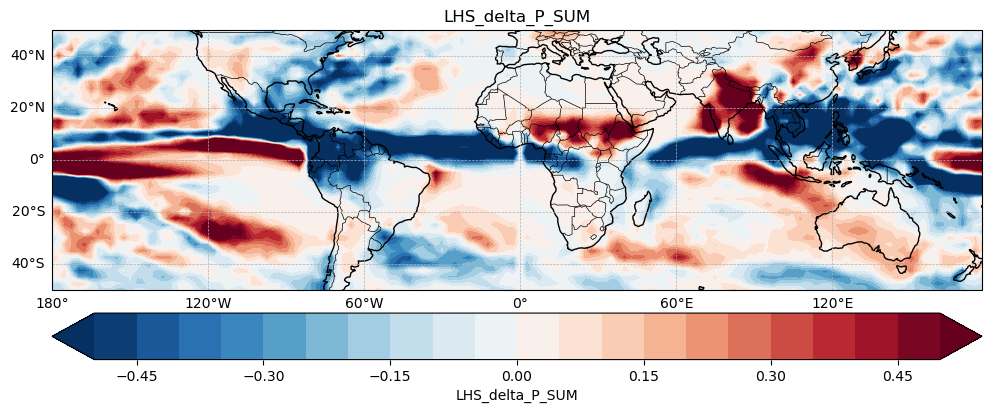

In [12]:
da = pr_comp['LHS_delta_P_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-0.5, vmax=0.5)

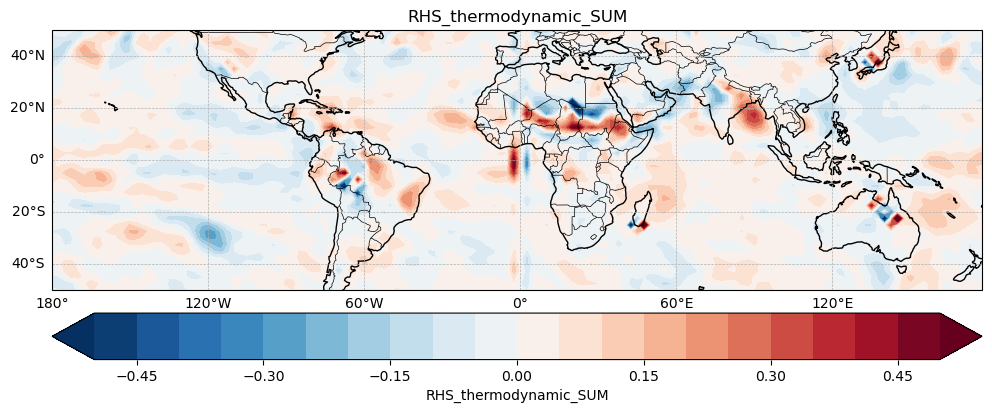

In [13]:
da = pr_comp['RHS_thermodynamic_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-0.5, vmax=0.5)

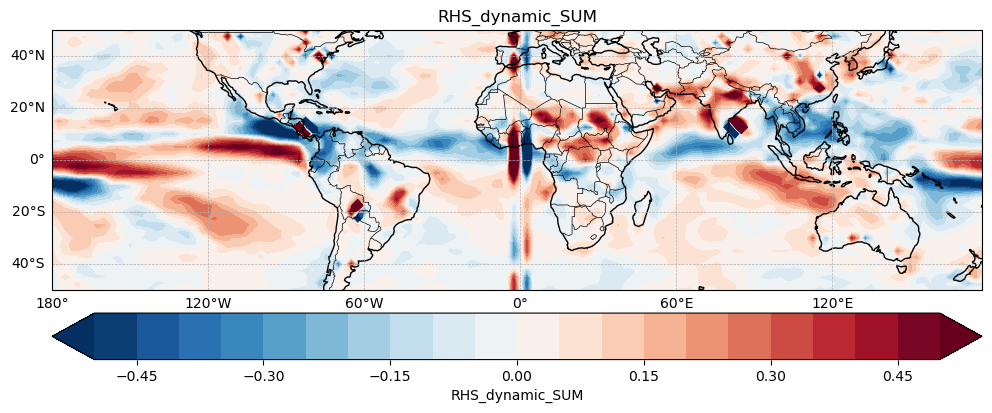

In [14]:
da = pr_comp['RHS_dynamic_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-0.5, vmax=0.5)

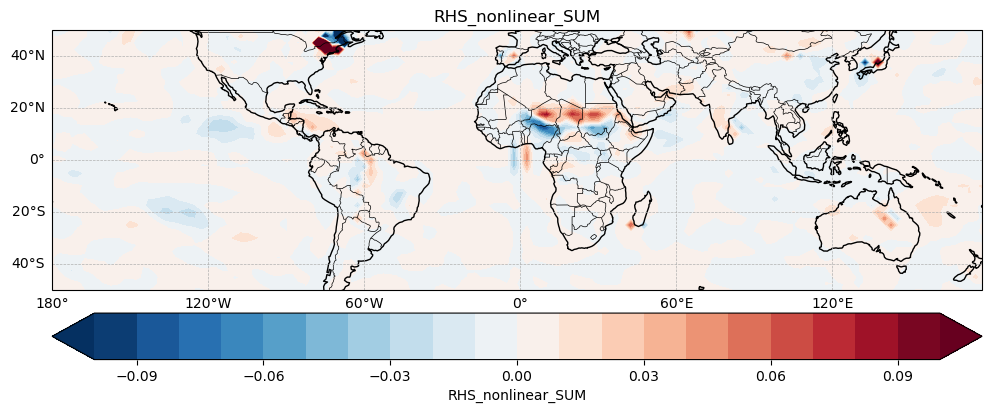

In [15]:
da = pr_comp['RHS_nonlinear_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-0.1, vmax=0.1)

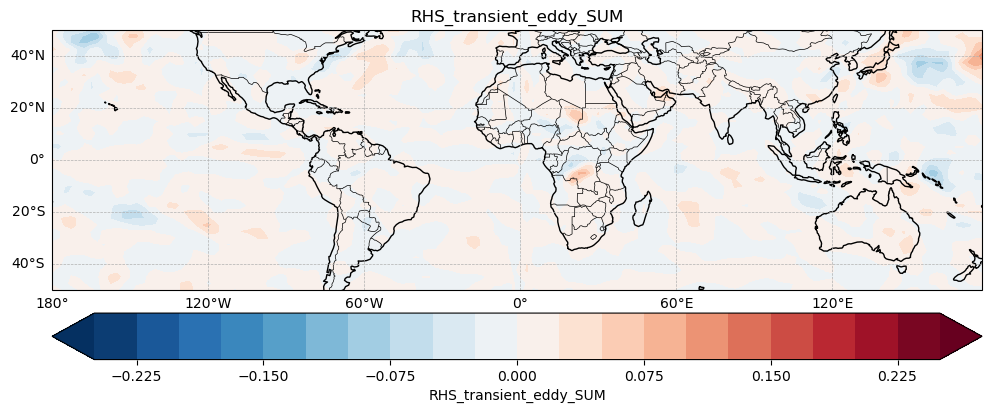

In [16]:
da = pr_comp['RHS_transient_eddy_SUM'].sel(model='UKESM1-0-LL')*86400
plot_map(da, vmin=-0.25, vmax=0.25)

In [17]:
print('da.max()', da.max())
print('da.min()', da.min())

da.max() <xarray.DataArray 'RHS_transient_eddy_SUM' ()> Size: 8B
array(0.11225435)
Coordinates:
    model    <U13 52B 'UKESM1-0-LL'
da.min() <xarray.DataArray 'RHS_transient_eddy_SUM' ()> Size: 8B
array(-0.09823077)
Coordinates:
    model    <U13 52B 'UKESM1-0-LL'


In [18]:
print("\n" + "="*60)
print("SEAGER DECOMPOSITION COMPONENTS")
print("="*60)

print("\nLEFT HAND SIDE (LHS):")
print("  • LHS_delta_P           : Total precipitation change (ΔP)")
print("  • LHS_delta_P_minus_E   : Moisture budget LHS (ΔP - ΔE)")

print("\nRIGHT HAND SIDE (RHS) - Seager Decomposition:")
print("  • RHS_thermodynamic     : -<V>·∇(Δq)")
print("                            Mean circulation advecting moisture change")
print("  • RHS_dynamic           : -ΔV·∇<q>")
print("                            Circulation change advecting mean moisture")
print("  • RHS_nonlinear         : -ΔV·∇(Δq)")
print("                            Circulation change advecting moisture change")
print("  • RHS_transient_eddy    : Δ<V'·∇q'>")
print("                            Change in transient eddy moisture flux convergence")

print("\nTOTAL:")
print("  • RHS_total             : thermodynamic + dynamic + nonlinear + transient_eddy")
print("                            (Should equal LHS_delta_P_minus_E)")

print("\nRESIDUAL:")
print("  • residual              : LHS_delta_P_minus_E - RHS_total")
print("                            (Measure of decomposition closure)")

print("\nADDITIONAL:")
print("  • delta_E               : Evaporation change (ΔE)")

print("\n" + "="*60)
print("DECOMPOSITION EQUATION:")
print("="*60)
print("ΔP - ΔE = Thermodynamic + Dynamic + Nonlinear + Transient Eddy")
print("="*60 + "\n")


SEAGER DECOMPOSITION COMPONENTS

LEFT HAND SIDE (LHS):
  • LHS_delta_P           : Total precipitation change (ΔP)
  • LHS_delta_P_minus_E   : Moisture budget LHS (ΔP - ΔE)

RIGHT HAND SIDE (RHS) - Seager Decomposition:
  • RHS_thermodynamic     : -<V>·∇(Δq)
                            Mean circulation advecting moisture change
  • RHS_dynamic           : -ΔV·∇<q>
                            Circulation change advecting mean moisture
  • RHS_nonlinear         : -ΔV·∇(Δq)
                            Circulation change advecting moisture change
  • RHS_transient_eddy    : Δ<V'·∇q'>
                            Change in transient eddy moisture flux convergence

TOTAL:
  • RHS_total             : thermodynamic + dynamic + nonlinear + transient_eddy
                            (Should equal LHS_delta_P_minus_E)

RESIDUAL:
  • residual              : LHS_delta_P_minus_E - RHS_total
                            (Measure of decomposition closure)

ADDITIONAL:
  • delta_E               : Evapor

In [19]:
def compute_regional_map(
    pr_comp,
    component_name,
    season="stitched",
    trop_bound=50,
    land_mask=None,
    agreement_threshold=4,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    """
    Plot regional map from Bony decomposition netCDF file.
    
    Parameters
    ----------
    pr_comp : xr.Dataset
        Bony decomposition dataset (e.g., from 'Bony_decomposition_G6sulfur_minus_SSP245.nc')
    component_name : str
        Component to plot. Options:
        - 'LHS_delta_P' : Total precipitation change
        - 'RHS_delta_P_therm' : Thermodynamic component
        - 'RHS_delta_P_dyn' : Dynamic component
        - 'RHS_delta_P_total' : Total reconstructed change
        - 'RHS_therm_delta_E' : Evaporation term
        - 'RHS_therm_omega_bar_times_delta_Gamma_q' : ω̄*ΔΓ_q term
        - 'RHS_therm_delta_H_q' : Horizontal advection term
        - 'RHS_therm_delta_Valpha_q' : Residual vertical advection term
        - 'RHS_dyn_Gamma_q_times_delta_omega_bar' : Dynamic term
        - 'residual' : LHS - RHS residual
    season : str, default 'stitched'
        Season to plot: 
        - 'stitched' : SUM for NH (lat>0), WIN for SH (lat<=0)
        - 'SUM' : JJA only
        - 'WIN' : DJF only
        - 'ANN' : Annual mean
    trop_bound : int, default 50
        Latitude boundary (not used when reading from netCDF, but kept for compatibility)
    land_mask : optional
        Land mask (not currently used)
    agreement_threshold : int, default 3
        Number of models that must agree on sign for stippling
    plot : bool, default True
        Whether to create the plot
    save_fig : bool, default False
        Whether to save the figure
    fig_path : str, optional
        Path to save figure
    
    Returns
    -------
    delta_mean : xr.DataArray
        Multi-model mean of the selected component
    stipple_mask : np.ndarray
        Boolean mask for model agreement stippling
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    # ------------------------------------------------------------------ #
    # Handle stitched vs single season
    # ------------------------------------------------------------------ #
    if season.lower() == "stitched":
        # Load both SUM and WIN
        var_name_sum = f"{component_name}_SUM"
        var_name_win = f"{component_name}_WIN"
        
        if var_name_sum not in pr_comp or var_name_win not in pr_comp:
            raise ValueError(
                f"Variables '{var_name_sum}' or '{var_name_win}' not found in dataset. "
                f"Available variables: {list(pr_comp.data_vars)}"
            )
        
        data_sum = pr_comp[var_name_sum]  # (model, lat, lon)
        data_win = pr_comp[var_name_win]  # (model, lat, lon)
        
        # Stitch: NH (lat > 0) = SUM, SH (lat <= 0) = WIN
        lat = data_sum.lat
        # Apply stitching - this preserves (model, lat, lon) dimension order
        stacked = xr.where(lat > 0, data_sum, data_win)
        
        season_label = "NH: JJA, SH: DJF"
        
    else:
        # Single season
        var_name = f"{component_name}_{season}"
        
        if var_name not in pr_comp:
            raise ValueError(
                f"Variable '{var_name}' not found in dataset. "
                f"Available variables: {list(pr_comp.data_vars)}"
            )
        
        stacked = pr_comp[var_name]  # (model, lat, lon)
        
        season_labels = {'SUM': 'JJA', 'WIN': 'DJF', 'ANN': 'Annual'}
        season_label = season_labels.get(season, season)
    
    # Ensure dimension order is (model, lat, lon)
    if 'model' in stacked.dims:
        stacked = stacked.transpose('model', 'lat', 'lon')
    
    # ------------------------------------------------------------------ #
    # Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #
    delta_mean = stacked.mean(dim="model").squeeze()
    
    sign_mean = np.sign(delta_mean.values)
    sign_models = np.sign(stacked.values)
    
    # sign_models shape: (model, lat, lon)
    # sign_mean shape: (lat, lon)
    # Need to broadcast: (model, lat, lon) == (1, lat, lon)
    n_agree = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold
    
    n_models = stacked.sizes['model']
    
    lat = delta_mean.lat.values
    lon = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)
    
    # Convert from kg m-2 s-1 to mm/day
    data_mm_day = data * 86400
    
    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    if plot:
        # vmax = float(np.nanpercentile(np.abs(data_mm_day), 98))
        vmax=0.5
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)
        
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        
        im = ax.contourf(LON, LAT, data_mm_day, levels=levels, cmap='RdBu_r',
                         extend='both', transform=ccrs.PlateCarree())
        
        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)
        
        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)
        
        # Get component label for plot
        component_labels = {
            'LHS_delta_P': 'Total ΔP',
            'RHS_delta_P_therm': 'Thermodynamic Component',
            'RHS_delta_P_dyn': 'Dynamic Component ($\Gamma_q \cdot \Delta \overline{\omega}$)',
            'RHS_delta_P_total': 'Total Reconstructed ΔP',
            'RHS_therm_delta_E': 'ΔE (Evaporation)',
            'RHS_therm_omega_bar_times_delta_Gamma_q': '$\overline{\omega} \cdot \Delta \Gamma_q$',
            'RHS_therm_delta_H_q': '$\Delta H_q$ (Horiz. Advection)',
            'RHS_therm_delta_Valpha_q': '$\Delta V^α_q$ (Resid. Vert. Advection)',
            'RHS_dyn_Gamma_q_times_delta_omega_bar': 'Γ_q·Δω̄', #Not needed, it is the dyn component
            'residual': 'Residual (LHS - RHS)'
        }
        
        comp_label = component_labels.get(component_name, component_name)
        
        cbar.set_label(f"{comp_label}  [mm day⁻¹]", fontsize=10)
        
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
                color='gray', linewidth=0.8, linestyle='--',
                transform=ccrs.PlateCarree())
        
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
        
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean: {comp_label}  ({season_label})\n"
            f"G6sulfur - SSP245  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)
        
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())
        
        plt.tight_layout()
        plt.show()
        
        if save_fig:
            season_suffix = "stitched" if season.lower() == "stitched" else season
            path = fig_path or f"{component_name}_{season_suffix}_G6sulfur_minus_SSP245.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")
    
    season_suffix = "stitched" if season.lower() == "stitched" else season
    # print(f"Returning → {component_name}_{season_suffix}")
    return delta_mean, stipple_mask

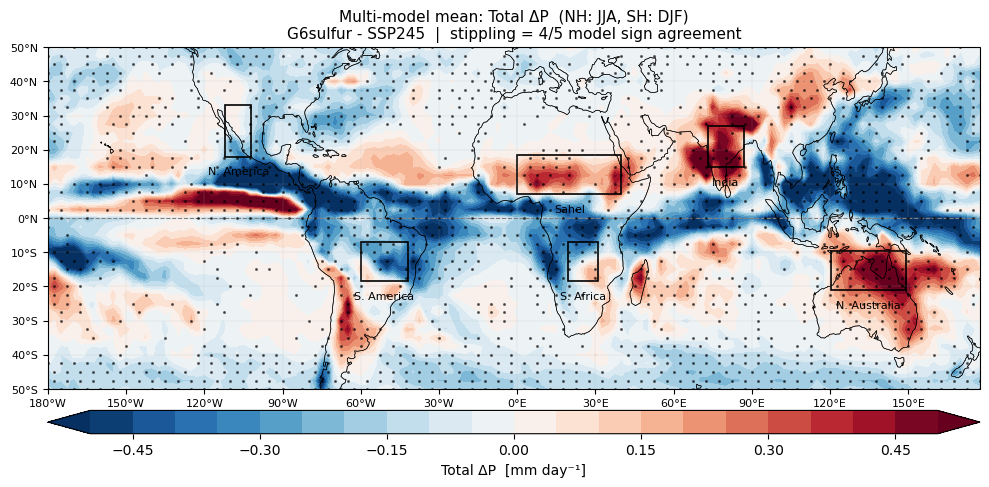

In [20]:
# Plot total precipitation change (annual)
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='LHS_delta_P',
    # season='stitched'  # This is the default
)

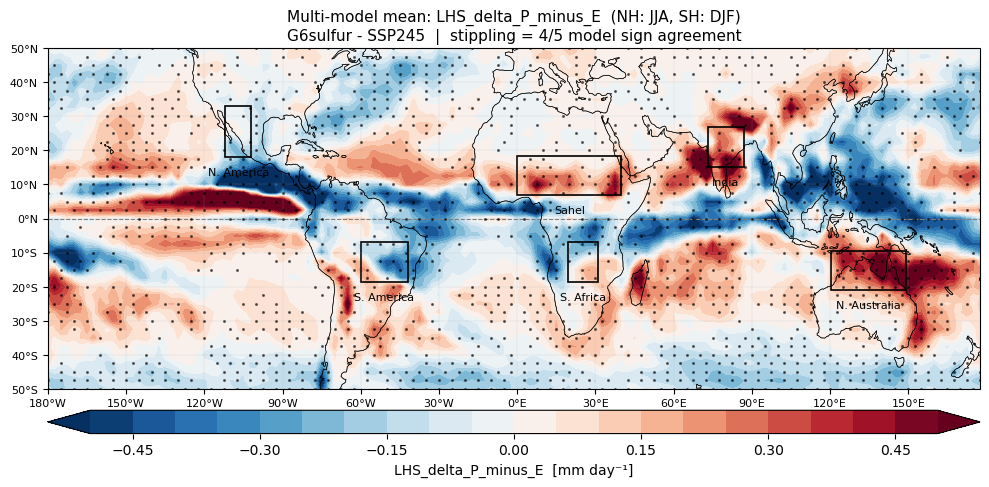

In [21]:
# Plot total precipitation change (annual)
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='LHS_delta_P_minus_E',
    # season='stitched'  # This is the default
)

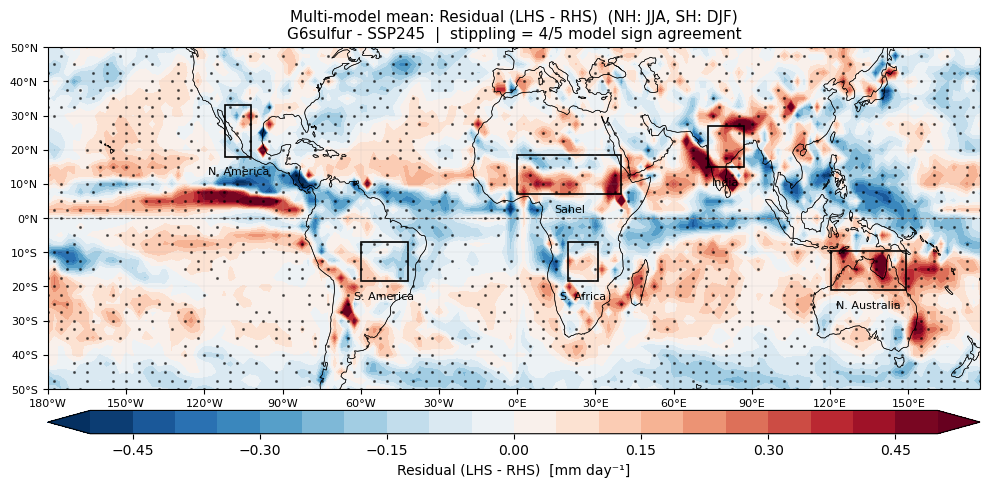

In [22]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='residual',
    # season='stitched'  # This is the default
)

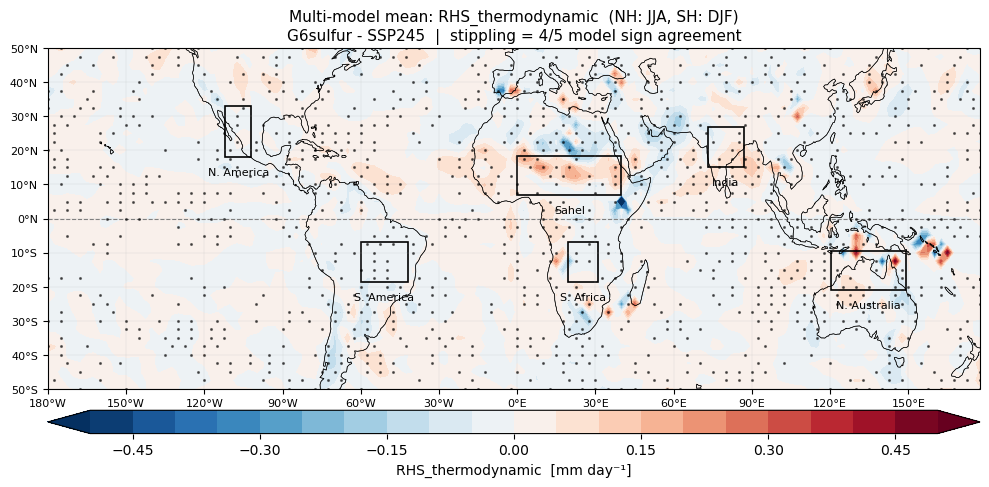

In [23]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_thermodynamic',
    # season='stitched'  # This is the default
)

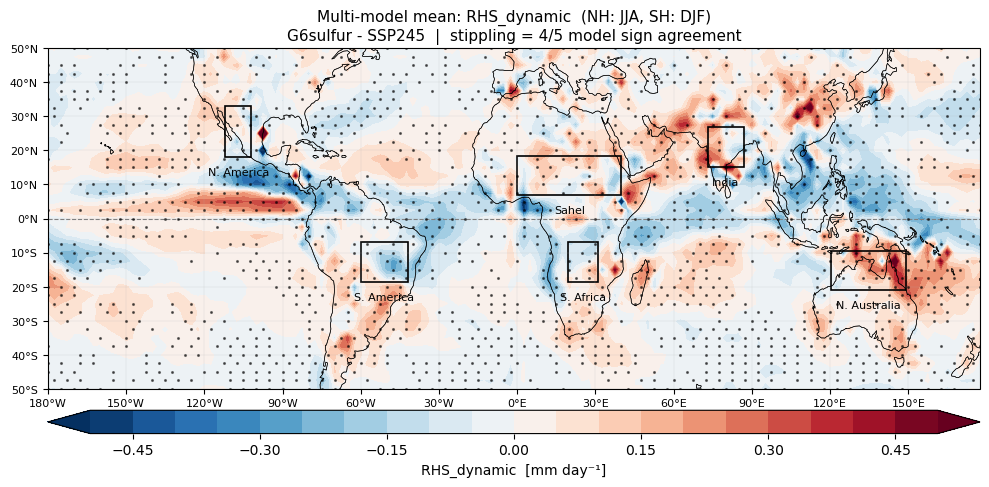

In [24]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_dynamic',
    # season='stitched'  # This is the default
)

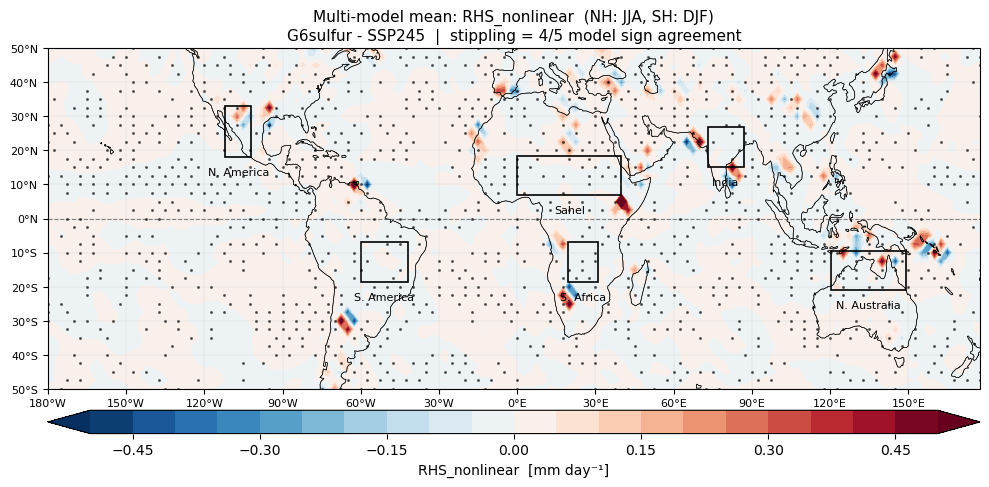

In [25]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_nonlinear',
    # season='stitched'  # This is the default
)

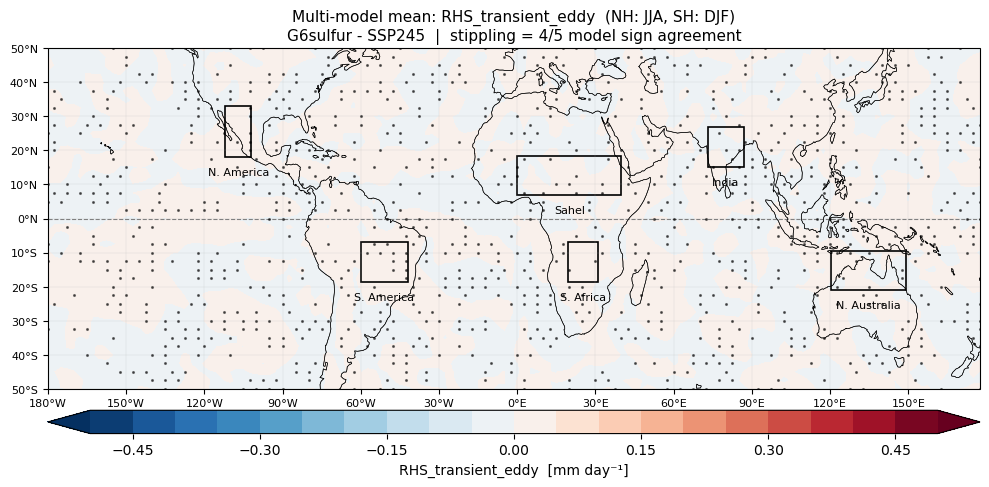

In [26]:
# Plot stitched map (default): SUM for NH, WIN for SH
delta_mean, stipple = compute_regional_map(
    pr_comp, 
    component_name='RHS_transient_eddy',
    # season='stitched'  # This is the default
)

# To plot the Φ(P) vertical profile

In [27]:
def plot_regional_decomposition_bars(
    pr_comp,
    set_1,
    set_2,
    season="stitched",
    plot_type="percentage",  # 'percentage' or 'absolute'
    show_error_bars=True,
    agreement_threshold=4,
    figsize=(12, 6),
    save_fig=False,
    fig_path=None,
):
    """
    Plot bar chart showing decomposition components for monsoon regions.
    
    Parameters
    ----------
    pr_comp : xr.Dataset
        Bony decomposition dataset
    set_1 : list of str
        Component(s) to use as denominator/total (e.g., ['LHS_delta_P'])
    set_2 : list of str
        Component(s) to decompose (e.g., ['RHS_delta_P_therm', 'RHS_delta_P_dyn'])
    season : str, default 'stitched'
        'stitched', 'SUM', 'WIN', or 'ANN'
    plot_type : str, default 'percentage'
        'percentage' (% contribution) or 'absolute' (mm/day)
    show_error_bars : bool, default True
        Whether to show model spread as error bars
    agreement_threshold : int, default 4
        Minimum models for agreement (not used in bars, kept for compatibility)
    figsize : tuple, default (12, 6)
        Figure size
    save_fig : bool, default False
        Whether to save figure
    fig_path : str, optional
        Path to save figure
    
    Returns
    -------
    fig, ax : matplotlib figure and axes
    regional_data : dict
        Dictionary with regional mean values and spreads
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import xarray as xr
    
    # Bombardi and Boos 2021 regions
    regions = {
        'N. America':   {'lon': (-112, -102),  'lat': (18,    33)},
        'S. America':   {'lon': (-60,  -42),   'lat': (-18.5, -7)},
        'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
        'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
        'India':        {'lon': (73,  87),   'lat': (15,    27)},
        'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
    }
    
    component_labels = {
        'LHS_delta_P': 'Total ΔP',
        'RHS_delta_P_therm': 'Thermodynamic',
        'RHS_delta_P_dyn': 'Dynamic',
        'RHS_delta_P_total': 'Reconstructed ΔP',
        'RHS_therm_delta_E': 'ΔE',
        'RHS_therm_omega_bar_times_delta_Gamma_q': r'$\overline{\omega} \cdot \Delta \Gamma_q$',
        'RHS_therm_delta_H_q': r'$\Delta H_q$',
        'RHS_therm_delta_Valpha_q': r'$\Delta V^{\alpha}_q$',
        'RHS_dyn_Gamma_q_times_delta_omega_bar': r'$\Gamma_q \cdot \Delta\overline{\omega}$',
        'residual': 'Residual'
    }
    
    # ------------------------------------------------------------------ #
    # Extract data for each component
    # ------------------------------------------------------------------ #
    def get_component_data(component_name, season):
        """Get stitched or single season data for a component."""
        if season.lower() == "stitched":
            var_name_sum = f"{component_name}_SUM"
            var_name_win = f"{component_name}_WIN"
            
            data_sum = pr_comp[var_name_sum]
            data_win = pr_comp[var_name_win]
            
            lat = data_sum.lat
            stacked = xr.where(lat > 0, data_sum, data_win)
        else:
            var_name = f"{component_name}_{season}"
            stacked = pr_comp[var_name]
        
        if 'model' in stacked.dims:
            stacked = stacked.transpose('model', 'lat', 'lon')
        
        return stacked * 86400  # Convert to mm/day
    
    # ------------------------------------------------------------------ #
    # Compute regional means
    # ------------------------------------------------------------------ #
    regional_data = {}
    
    for region_name, coords in regions.items():
        regional_data[region_name] = {}
        
        lon0, lon1 = coords['lon']
        lat0, lat1 = coords['lat']
        
        # Handle longitude wrapping (e.g., 248-258 crosses 360->0)
        for comp_name in set_1 + set_2:
            data = get_component_data(comp_name, season)
            
            # Select region (simple case, no wrapping needed)
            mask_lon = (data.lon >= lon0) & (data.lon <= lon1)
            mask_lat = (data.lat >= lat0) & (data.lat <= lat1)
            
            # Select and compute regional mean for each model
            regional = data.where(mask_lat & mask_lon, drop=True)
            regional_mean_per_model = regional.mean(dim=['lat', 'lon'])
            
            # Multi-model mean and std
            mean_val = regional_mean_per_model.mean(dim='model').values
            std_val = regional_mean_per_model.std(dim='model').values
            
            regional_data[region_name][comp_name] = {
                'mean': mean_val,
                'std': std_val
            }
    
    # ------------------------------------------------------------------ #
    # Compute percentages if needed
    # ------------------------------------------------------------------ #
    if plot_type == "percentage":
        # Compute percentages WHILE PRESERVING SIGN RELATIVE TO ABSOLUTE VALUES
        for region_name in regional_data:
            total = sum(regional_data[region_name][comp]['mean'] for comp in set_1)
            
            for comp in set_2:
                if abs(total) > 1e-10:  # Avoid division by zero
                    # Use abs(total) to preserve the original sign direction
                    regional_data[region_name][comp]['percentage'] = (
                        regional_data[region_name][comp]['mean'] / abs(total) * 100
                    )
                    # Error propagation
                    regional_data[region_name][comp]['percentage_std'] = (
                        regional_data[region_name][comp]['std'] / abs(total) * 100
                    )
                else:
                    regional_data[region_name][comp]['percentage'] = 0
                    regional_data[region_name][comp]['percentage_std'] = 0
    
    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(figsize=figsize)
    
    region_names = list(regions.keys())
    x = np.arange(len(region_names))
    width = 0.8 / len(set_2)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(set_2)))
    
    if plot_type == "percentage":
        # Separate positive and negative contributions
        pos_bottom = np.zeros(len(region_names))
        neg_bottom = np.zeros(len(region_names))
        
        for i, comp in enumerate(set_2):
            values = np.array([regional_data[reg][comp]['percentage'] for reg in region_names])
            errors = [regional_data[reg][comp]['percentage_std'] for reg in region_names] if show_error_bars else None
            
            label = component_labels.get(comp, comp)
            
            # Determine if positive or negative
            pos_values = np.where(values >= 0, values, 0)
            neg_values = np.where(values < 0, values, 0)
            
            # Plot positive contributions stacked upward
            if np.any(pos_values > 0):
                ax.bar(x, pos_values, width=0.6, bottom=pos_bottom, 
                       label=label, color=colors[i], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
                pos_bottom += pos_values
            
            # Plot negative contributions stacked downward
            if np.any(neg_values < 0):
                ax.bar(x, neg_values, width=0.6, bottom=neg_bottom,
                       color=colors[i], alpha=0.8,
                       edgecolor='black', linewidth=0.5)
                neg_bottom += neg_values
            
            if show_error_bars and errors is not None:
                ax.errorbar(x, values, yerr=errors, fmt='none', 
                           ecolor='black', elinewidth=1, capsize=3, alpha=0.6)
        
        ax.set_ylabel('Contribution (%)', fontsize=12)
        ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        # Add reference line name
        total_label = ' + '.join([component_labels.get(c, c) for c in set_1])
        ax.text(0.02, 0.98, f'Relative to: {total_label}', 
               transform=ax.transAxes, fontsize=9, va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
    else:  # absolute
        # Grouped bars for absolute values
        for i, comp in enumerate(set_2):
            values = [regional_data[reg][comp]['mean'] for reg in region_names]
            errors = [regional_data[reg][comp]['std'] for reg in region_names] if show_error_bars else None
            
            label = component_labels.get(comp, comp)
            offset = (i - len(set_2)/2 + 0.5) * width
            
            bars = ax.bar(x + offset, values, width, 
                         label=label, color=colors[i], alpha=0.8,
                         edgecolor='black', linewidth=0.5,
                         yerr=errors if show_error_bars else None,
                         capsize=3, error_kw={'elinewidth': 1, 'alpha': 0.6})
        
        ax.set_ylabel('ΔP (mm day⁻¹)', fontsize=12)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_xlabel('Monsoon Region', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=15, ha='right')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    
    season_labels = {'stitched': 'NH: JJA, SH: DJF', 'SUM': 'JJA', 'WIN': 'DJF', 'ANN': 'Annual'}
    season_label = season_labels.get(season.lower(), season)
    
    title = f"Precipitation Decomposition by Region ({season_label})\n"
    if plot_type == "percentage":
        title += f"Contribution to: {total_label}"
    else:
        title += "Absolute Changes (G6sulfur - SSP585)"
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    
    if save_fig:
        season_suffix = "stitched" if season.lower() == "stitched" else season
        path = fig_path or f"regional_decomposition_{plot_type}_{season_suffix}.png"
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax, regional_data

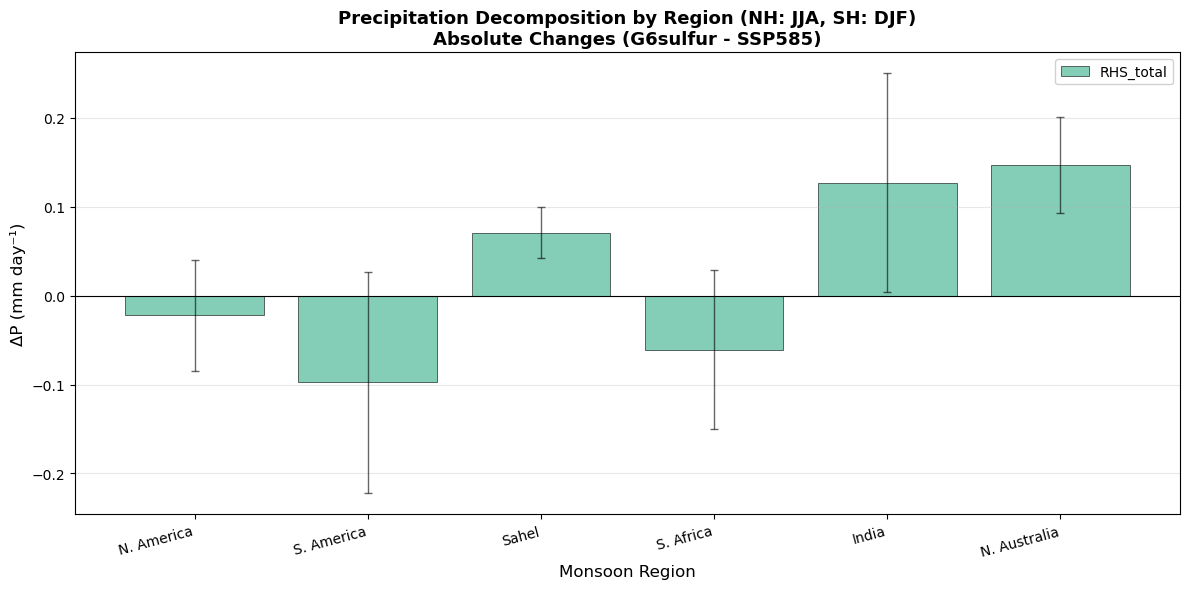

In [28]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P_minus_E'],
    set_2=['RHS_total'],
    season='stitched',
    plot_type='absolute'
)

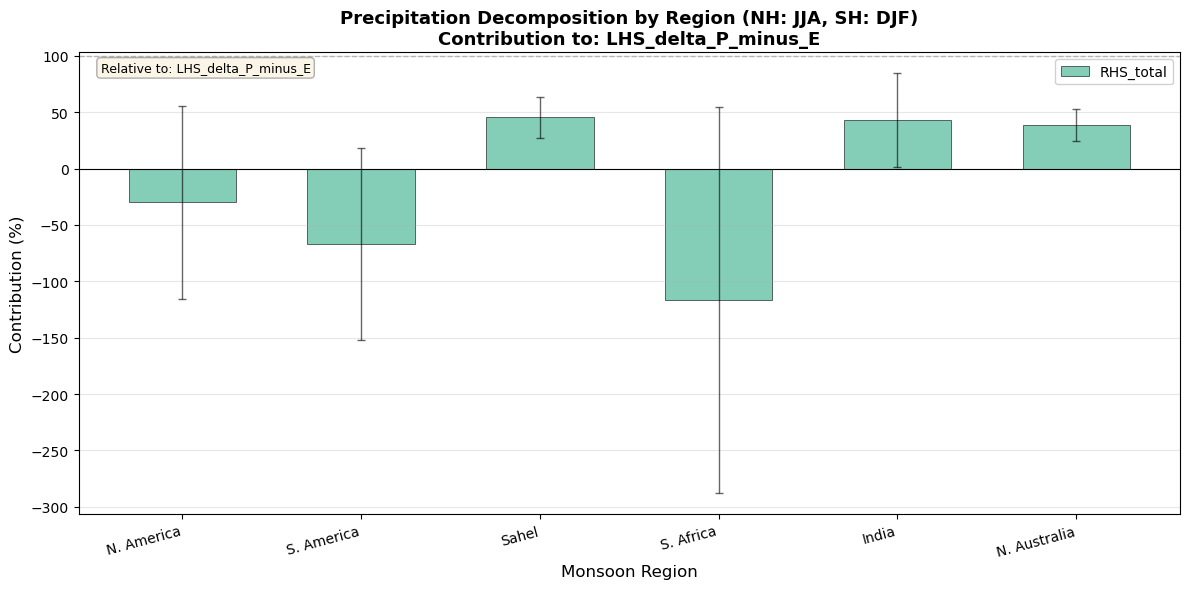

In [29]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P_minus_E'],
    set_2=['RHS_total'],
    season='stitched',
    plot_type='percentage',
)

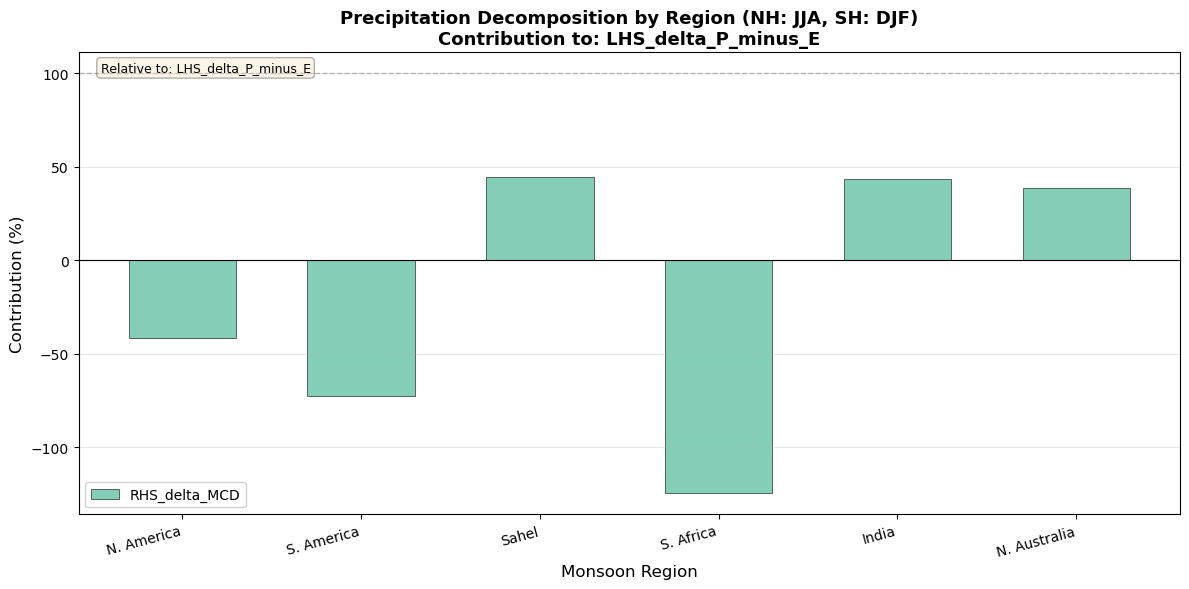

In [30]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P_minus_E'],
    set_2=['RHS_delta_MCD'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False
)

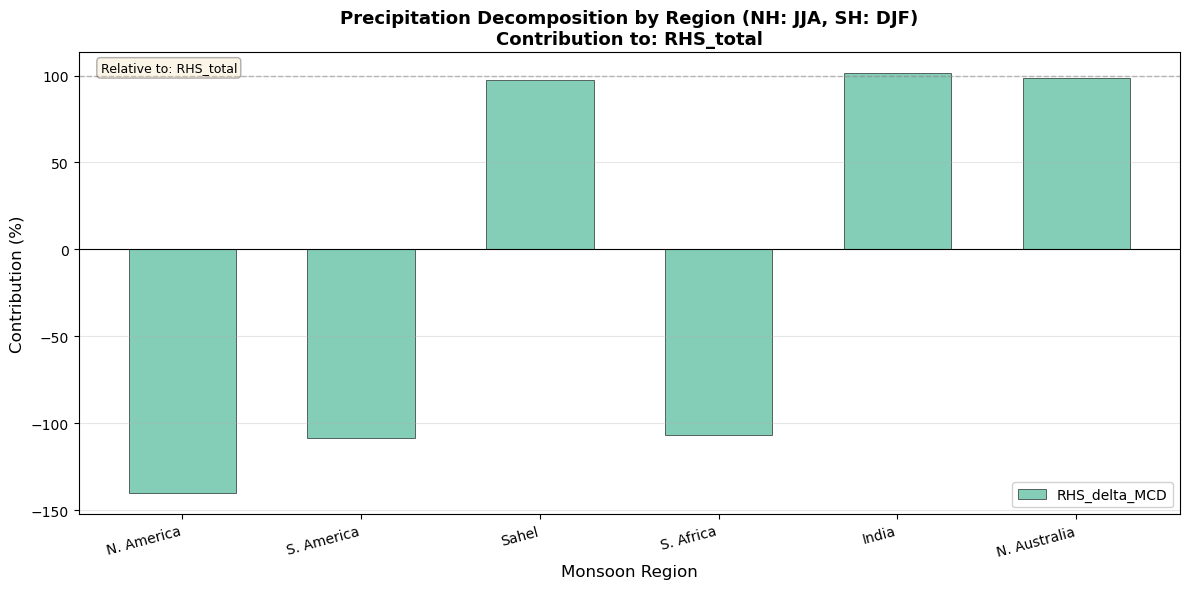

In [31]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['RHS_total'],
    set_2=['RHS_delta_MCD'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False
)

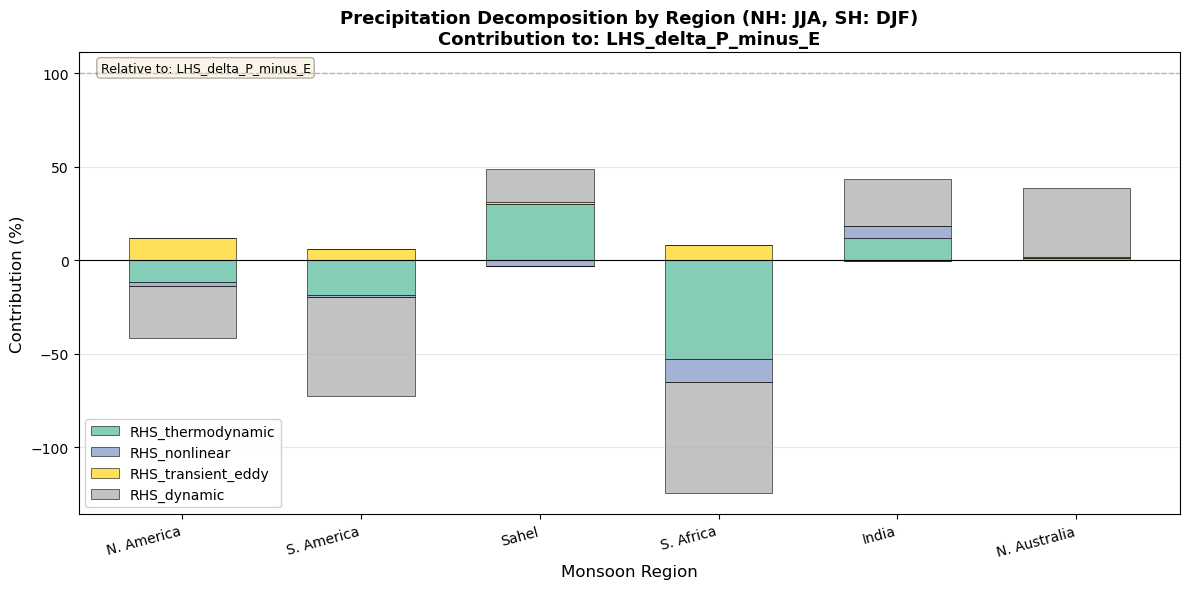

In [32]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P_minus_E'],
    set_2=['RHS_thermodynamic','RHS_nonlinear','RHS_transient_eddy','RHS_dynamic'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False)

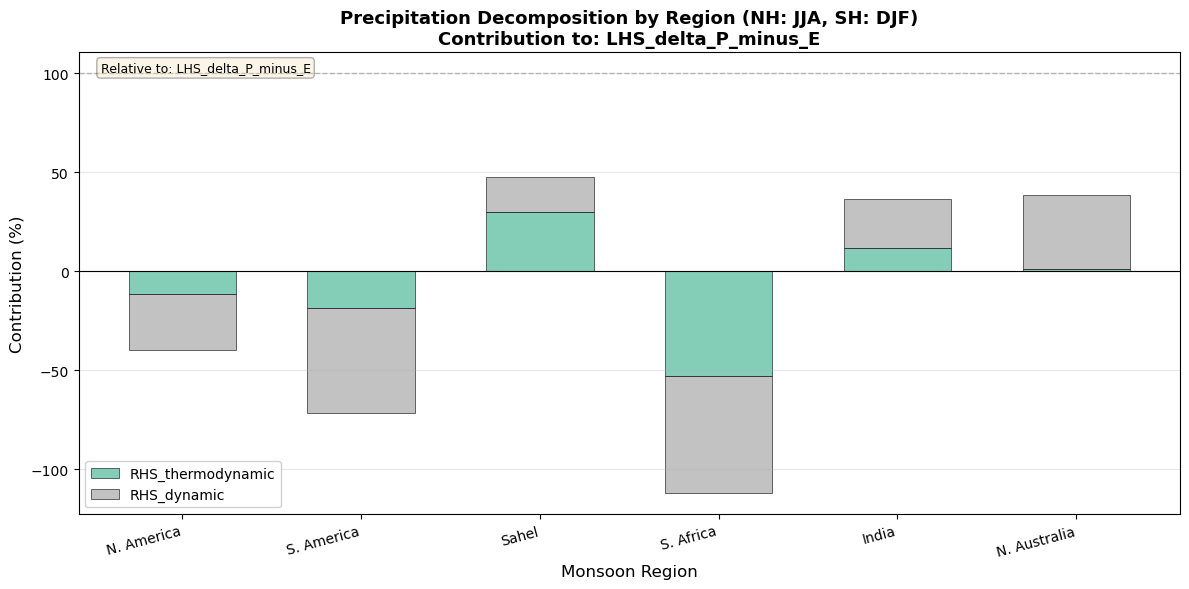

In [33]:
# Example 1: How well does reconstructed ΔP match total ΔP?
fig, ax, data = plot_regional_decomposition_bars(
    pr_comp,
    set_1=['LHS_delta_P_minus_E'],
    set_2=['RHS_thermodynamic','RHS_dynamic'],
    season='stitched',
    plot_type='percentage',
    show_error_bars=False)